In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [35]:
warnings.filterwarnings('ignore')

In [36]:
df=pd.read_csv('/content/Combined Data.csv')

In [37]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [38]:
df.drop(columns='Unnamed: 0',inplace=True)

In [39]:
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [40]:
df.shape

(53044, 2)

In [41]:
df['status'].value_counts()

,count
status,
Normal,16351
Depression,15404
Suicidal,10652
Anxiety,3888
Bipolar,2877
Stress,2669
Personality disorder,1201


In [42]:
df.isnull().sum()

,0
statement,363
status,2


In [43]:
# df = df.dropna(subset=["statement"])
df.dropna(inplace=True)

In [44]:
df.isnull().sum()

,0
statement,0
status,0


In [45]:
df.duplicated().sum()

np.int64(1592)

In [46]:
# df = df.drop_duplicates()
df.drop_duplicates(inplace=True)

In [47]:
df.duplicated().sum()

np.int64(0)

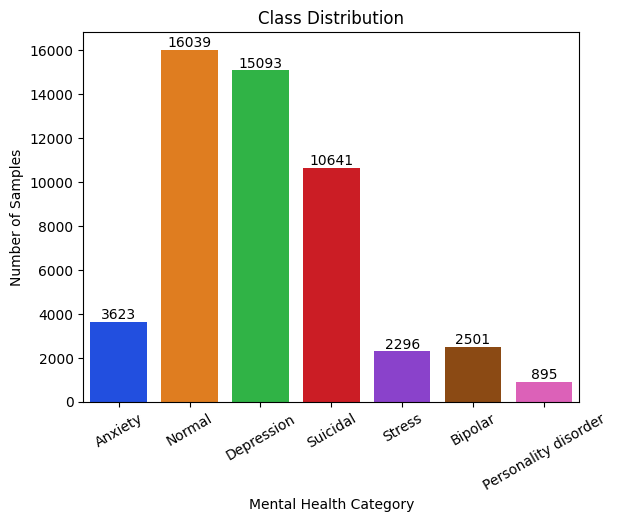

In [48]:
ax=sns.countplot(data=df, x="status", palette="bright")
for i in ax.containers:
  ax.bar_label(i)

plt.title("Class Distribution")
plt.xlabel("Mental Health Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.show()

In [49]:
# for label in df["status"].unique():
#     print("="*50)
#     print(label)
#     print(df[df["status"] == label]["statement"].iloc[0])

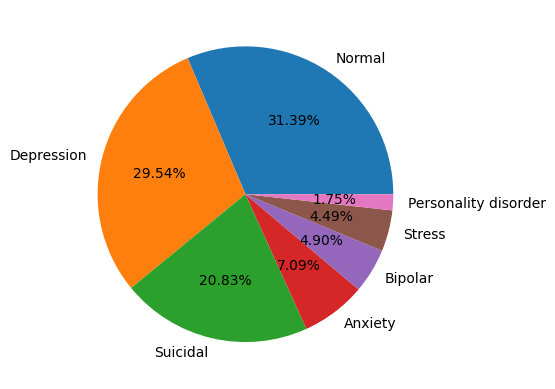

In [50]:
counts = df['status'].value_counts()
labels = counts.index

plt.pie(counts, labels=labels, autopct='%1.2f%%')
plt.show()

In [51]:
# df["word_count"] = df["statement"].apply(lambda x: len(str(x).split()))
df["word_count"] = df["statement"].str.split().str.len()

In [52]:
df.head()

,statement,status,word_count
0,oh my gosh,Anxiety,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14
3,I've shifted my focus to something else but I'...,Anxiety,11
4,"I'm restless and restless, it's been a month n...",Anxiety,14


In [53]:
df["word_count"].describe()

,word_count
count,51088.000000
mean,112.595854
std,161.828670
min,1.000000
25%,15.000000
50%,61.000000
75%,147.000000
max,5419.000000


<Axes: ylabel='Frequency'>

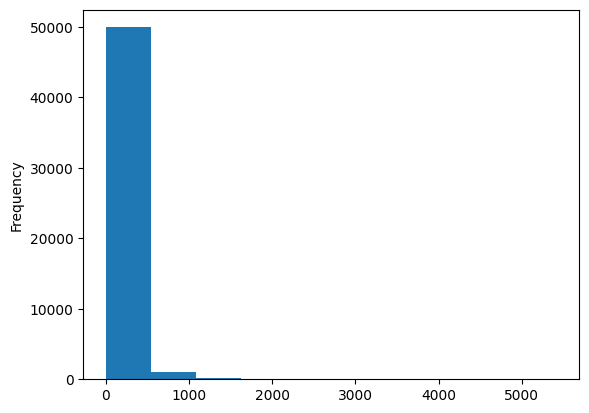

In [54]:
df['word_count'].plot(kind='hist')

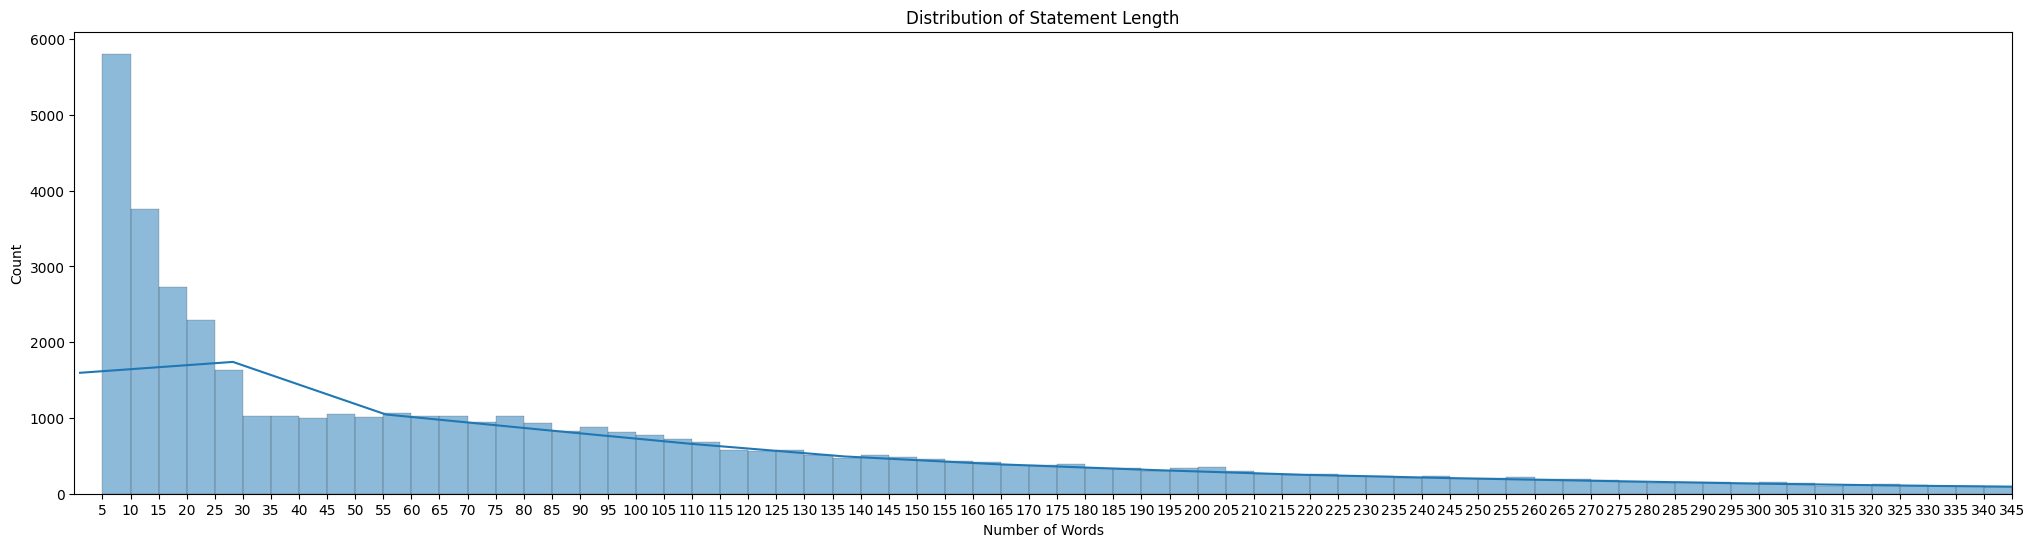

In [55]:
plt.figure(figsize=(25, 6))  # Slightly wider figure so the numbers don't overlap

# Define the sequence from 5 up to 100 (inclusive of 100) with a step of 5
custom_bins = list(range(5, 1000, 5))

# Pass the sequence to the bins parameter
sns.histplot(df["word_count"], bins=custom_bins, kde=True)

# Zoom in on the 0 to 105 range so the last bin fits nicely
plt.xlim(0, 105)

# Set the x-axis tick marks exactly at your bin intervals
plt.xticks(list(range(5, 350, 5)))

plt.title("Distribution of Statement Length")
plt.xlabel("Number of Words")
plt.show()

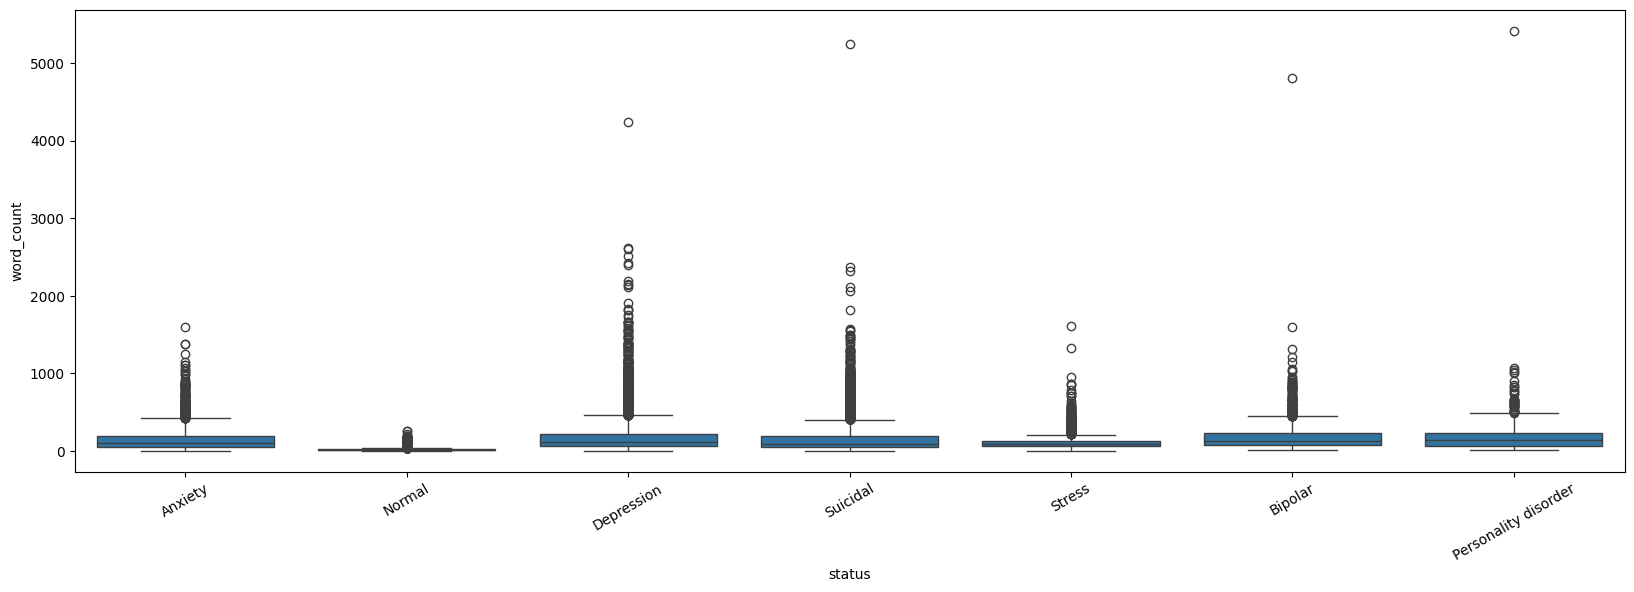

In [56]:
plt.figure(figsize=(20,6))

sns.boxplot(
    data=df,
    x="status",
    y="word_count"
)

plt.xticks(rotation=30)

plt.show()

In [57]:
df["char_count"] = df["statement"].apply(len)
df["char_count"].describe()

,char_count
count,51088.000000
mean,574.997377
std,835.943210
min,2.000000
25%,79.000000
50%,313.000000
75%,745.250000
max,27588.000000


In [58]:
df["avg_word_length"] = df["statement"].apply(
    lambda x: np.mean([len(word) for word in str(x).split()]))

df["avg_word_length"].describe()

,avg_word_length
count,51088.000000
mean,4.320150
std,14.082419
min,1.100000
25%,3.823529
50%,4.089552
75%,4.428571
max,3161.875000


In [59]:
all_words = []

for sentence in df["statement"]:
    all_words.extend(sentence.lower().split())

len(set(all_words))

138957

In [60]:
from collections import Counter
word_freq = Counter(all_words)

word_freq.most_common(20)

[('i', 387051),
 ('to', 188979),
 ('and', 168278),
 ('the', 122145),
 ('my', 115178),
 ('a', 113268),
 ('of', 81404),
 ('not', 73072),
 ('it', 70134),
 ('is', 68827),
 ('have', 67327),
 ('that', 62347),
 ('am', 60562),
 ('in', 58485),
 ('me', 54828),
 ('but', 53782),
 ('for', 51726),
 ('do', 51135),
 ('just', 47048),
 ('so', 40534)]

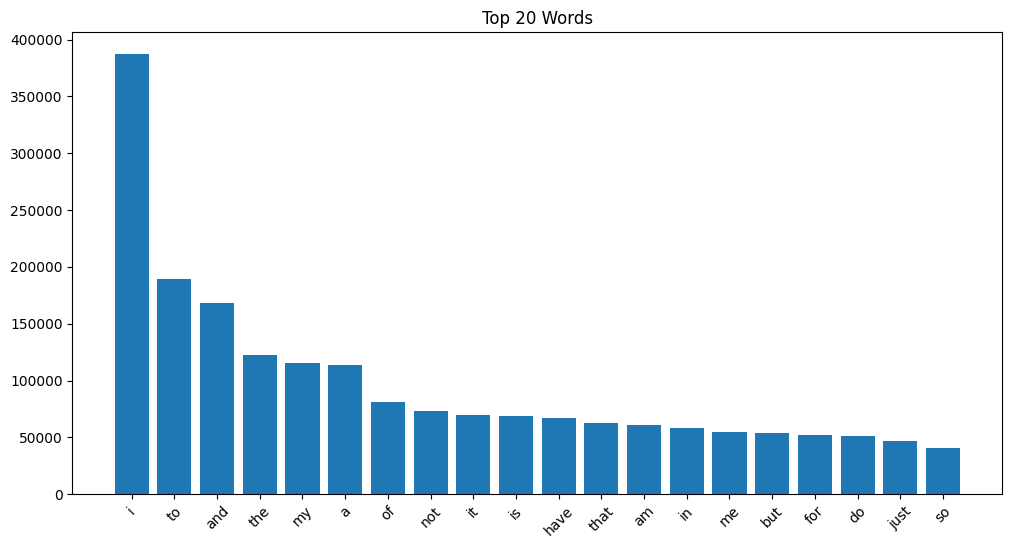

In [61]:
common = word_freq.most_common(20)

words = [w[0] for w in common]
counts = [w[1] for w in common]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Words")

plt.show()

In [33]:
pip install WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 15.6 MB/s eta 0:00:00


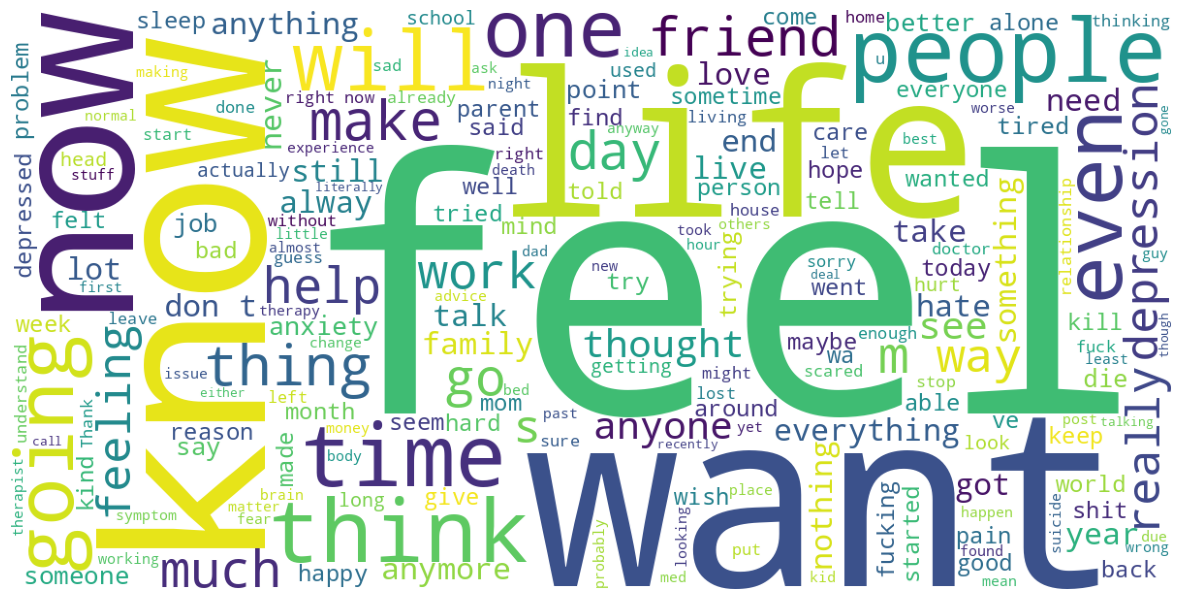

In [62]:
from wordcloud import WordCloud

text = " ".join(df["statement"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

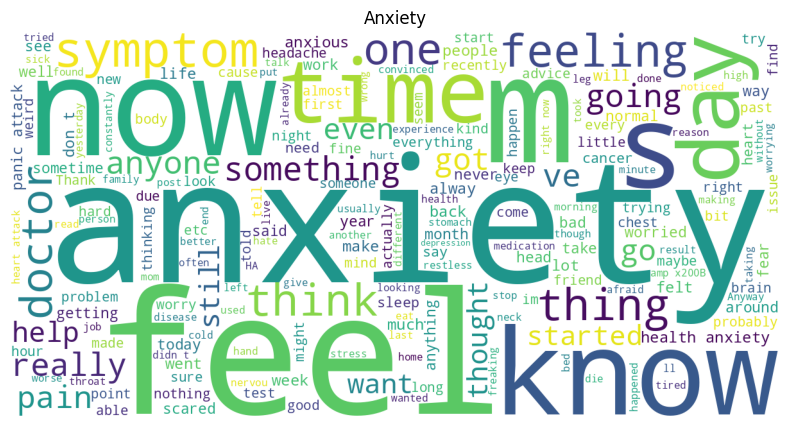

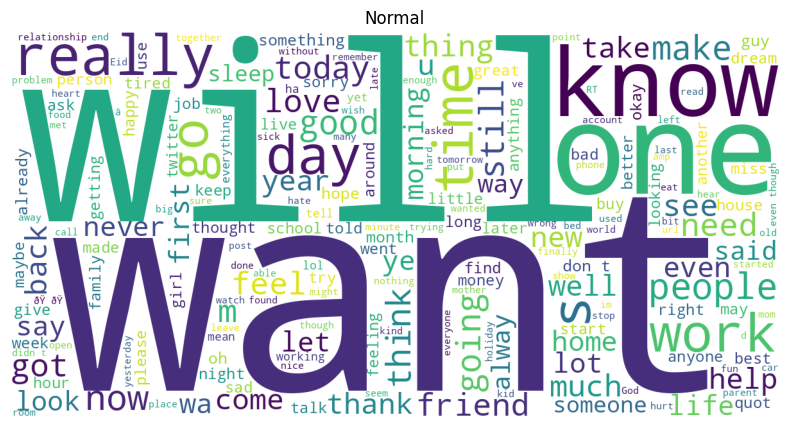

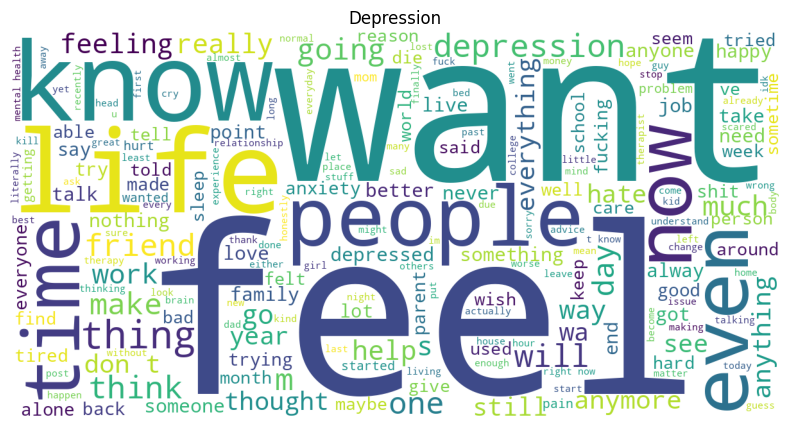

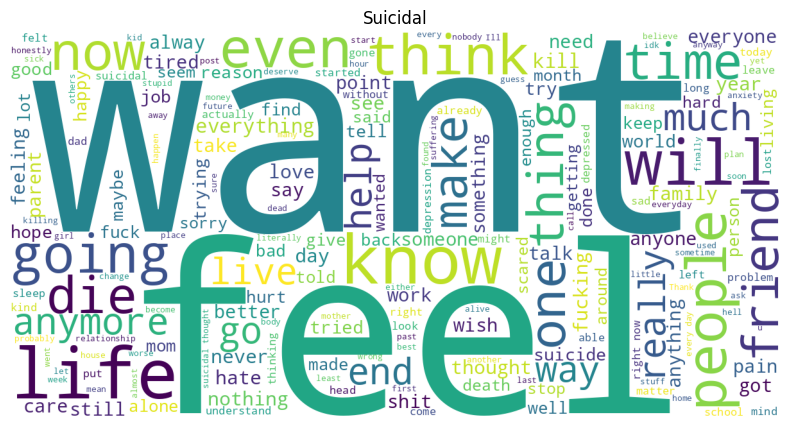

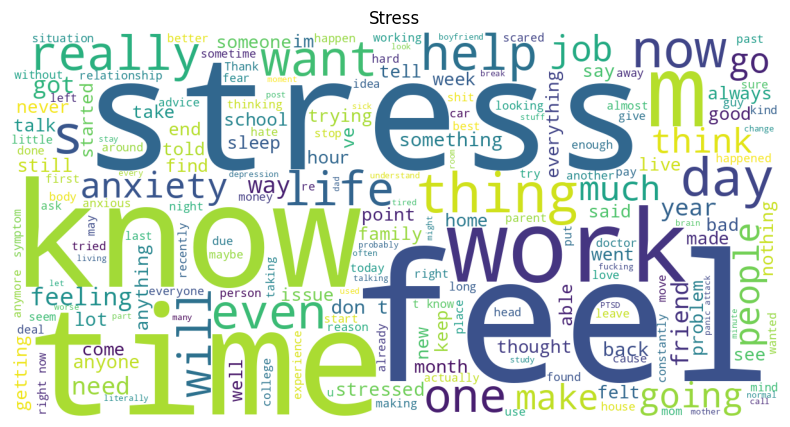

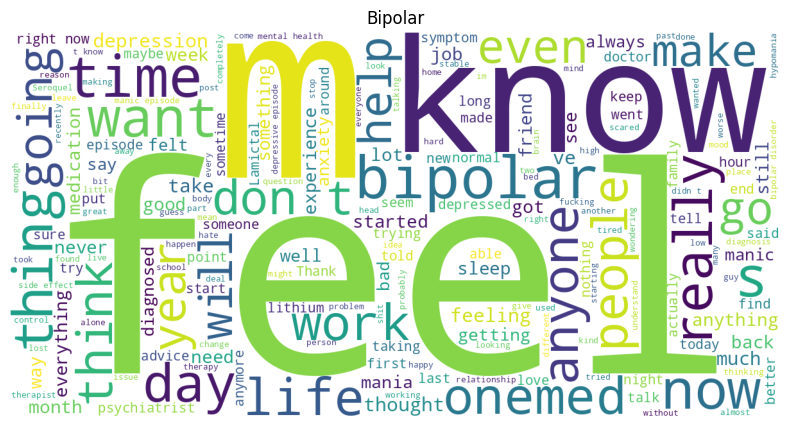

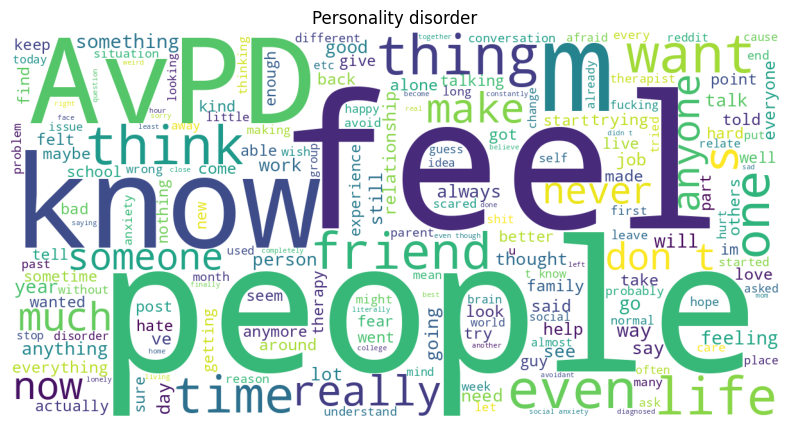

In [63]:
for label in df["status"].unique():

    text = " ".join(
        df[df["status"] == label]["statement"]
    )

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))

    plt.imshow(wordcloud)

    plt.axis("off")

    plt.title(label)

    plt.show()

In [64]:
import nltk
from nltk.util import ngrams
from collections import Counter
nltk.download('punkt')

tokens = []

for sentence in df["statement"]:
    tokens.extend(sentence.lower().split())

bigrams = list(ngrams(tokens,2))

Counter(bigrams).most_common(20)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


[(('i', 'am'), 54864),
 (('i', 'have'), 37059),
 (('and', 'i'), 28280),
 (('do', 'not'), 26225),
 (('i', 'do'), 22050),
 (('want', 'to'), 20067),
 (('but', 'i'), 17463),
 (('i', 'was'), 17056),
 (('i', 'just'), 14864),
 (('i', 'feel'), 14768),
 (('that', 'i'), 14601),
 (('to', 'be'), 13391),
 (('feel', 'like'), 10974),
 (('in', 'the'), 10652),
 (('when', 'i'), 9649),
 (('i', 'cannot'), 9459),
 (('it', 'is'), 9447),
 (('in', 'my'), 9309),
 (('i', 'can'), 9289),
 (('because', 'i'), 8808)]

In [65]:
trigrams = list(ngrams(tokens,3))

Counter(trigrams).most_common(20)

[(('i', 'do', 'not'), 18500),
 (('i', 'feel', 'like'), 6741),
 (('i', 'want', 'to'), 6624),
 (('i', 'have', 'been'), 5698),
 (('do', 'not', 'want'), 5476),
 (('do', 'not', 'know'), 5468),
 (('not', 'want', 'to'), 4915),
 (('i', 'am', 'not'), 4682),
 (('feel', 'like', 'i'), 4104),
 (('and', 'i', 'am'), 4069),
 (('i', 'just', 'want'), 3618),
 (('just', 'want', 'to'), 3129),
 (('i', 'am', 'just'), 2980),
 (('i', 'have', 'no'), 2937),
 (('i', 'am', 'so'), 2842),
 (('i', 'have', 'a'), 2754),
 (('a', 'lot', 'of'), 2716),
 (('want', 'to', 'be'), 2662),
 (('do', 'not', 'have'), 2596),
 (('that', 'i', 'am'), 2486)]

In [66]:
df["statement"].str.contains("http", case=False).sum()

np.int64(988)

In [67]:
df["statement"].str.contains("@").sum()

np.int64(941)

In [68]:
df["statement"].str.contains(r"\d", regex=True).sum()

np.int64(16250)

In [69]:
df["statement"].str.contains("<.*?>", regex=True).sum()

np.int64(126)

In [70]:
df["statement"].str.contains(r"\s{2,}", regex=True).sum()

np.int64(5302)

## EDA Findings Report

This report summarizes the key observations and insights from the exploratory data analysis performed on the mental health statements dataset.

### 1. Initial Data Overview and Cleaning

*   **Initial Shape**: The dataset originally contained 53,043 rows and 2 columns ('statement' and 'status').
*   **Missing Values**: 362 missing values were identified in the 'statement' column. These were subsequently removed, resulting in a cleaner dataset.
*   **Duplicate Entries**: 1,588 duplicate rows were found and removed from the dataset, ensuring each statement is unique for analysis.

### 2. Class Distribution ('status')

*   The dataset is comprised of seven mental health categories: Normal, Depression, Suicidal, Anxiety, Bipolar, Stress, and Personality disorder.
*   **Distribution**: The 'Normal' and 'Depression' categories are the most prevalent, accounting for approximately 31.39% and 29.54% of the data, respectively. 'Suicidal' statements represent about 20.83%.
*   **Imbalance**: There is a significant class imbalance, with 'Personality disorder' being the least represented category at 1.75% (895 samples) and 'Normal' being the most prevalent with 16,040 samples. This imbalance may need to be addressed during model training to prevent bias towards majority classes.

### 3. Statement Length Analysis

*   **Word Count**:
    *   The average statement length is approximately 112.7 words, with a minimum of 1 and a maximum of 6,300 words.
    *   The distribution of word counts is highly skewed to the right, indicating that most statements are relatively short, while a few are very long. This is evident in the histogram, where a large peak is observed for statements with fewer than 100 words.
*   **Character Count**:
    *   Statements have an average of 575.6 characters, ranging from 2 to 32,759 characters.
*   **Average Word Length**: The average word length across all statements is about 4.32 characters.
*   **Box Plot by Status**: The box plot shows that while most statements across all categories are relatively short, there are significant outliers (very long statements) present in all categories, particularly in 'Depression' and 'Suicidal'. This suggests that statement length itself might not be a strong distinguishing feature for categories but the presence of extremely long statements might be relevant.

### 4. Word Frequency Analysis

*   **Unique Words**: There are 138,966 unique words in the dataset.
*   **Most Common Words**: The top 20 most frequent words are predominantly stopwords (e.g., 'i', 'to', 'and', 'the', 'my', 'a', 'of', 'not', 'it', 'is', 'have'). These words provide little semantic meaning and are candidates for removal during text preprocessing.
*   **Bigrams**: The most common two-word sequences (bigrams) include 'i am', 'i have', 'and i', 'do not', and 'i do'. These often reflect common grammatical structures and expressions.
*   **Trigrams**: Common three-word sequences (trigrams) like 'i do not', 'i feel like', and 'i want to' further highlight frequently used phrases, which could be indicative of the nature of statements in a mental health context.

### 5. Special Character and Pattern Analysis

*   **URLs**: 988 statements contain URLs ('http' or 'https'), indicating external links or references.
*   **Mentions**: 941 statements include the '@' symbol, suggesting mentions of users or entities.
*   **Digits**: A significant number of statements (16,251) contain numerical digits.
*   **HTML Tags**: A small number of statements (126) contain HTML-like tags (`<.*?>`), which might indicate data scraped from web sources.
*   **Multiple Spaces**: 5,302 statements have occurrences of two or more consecutive spaces, suggesting potential irregularities in text formatting that might need normalization.

In [71]:
df.groupby("status")["word_count"].mean()

,word_count
status,
Anxiety,143.139111
Bipolar,178.274690
Depression,168.250447
Normal,17.434877
Personality disorder,177.851397
Stress,111.665941
Suicidal,145.967014


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


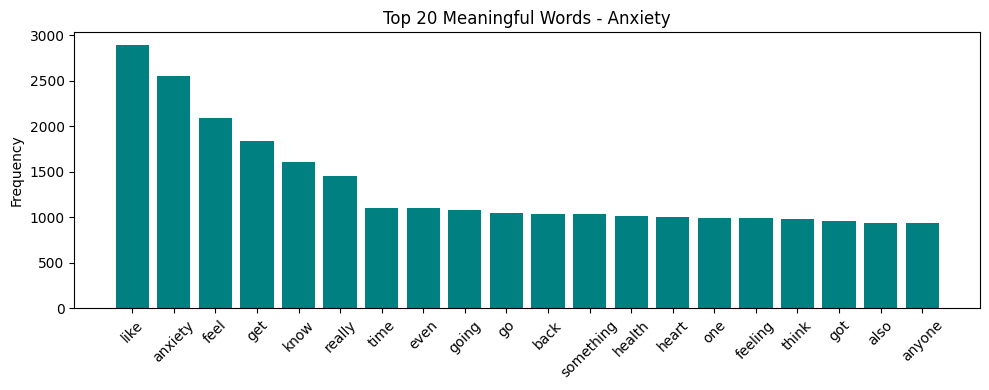

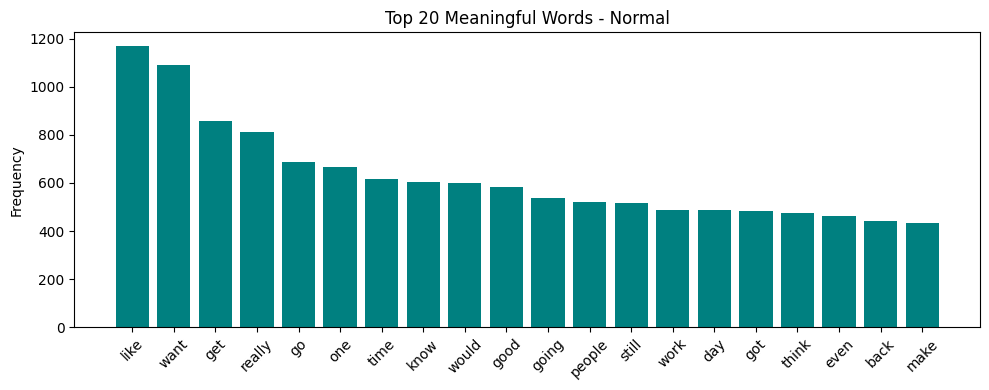

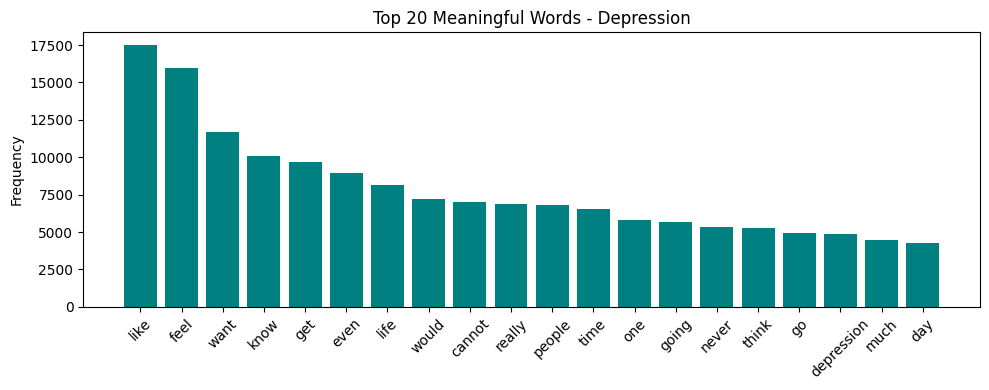

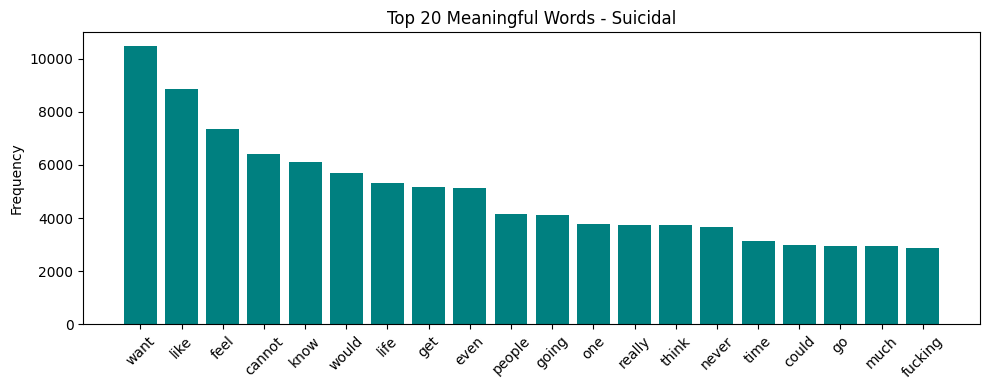

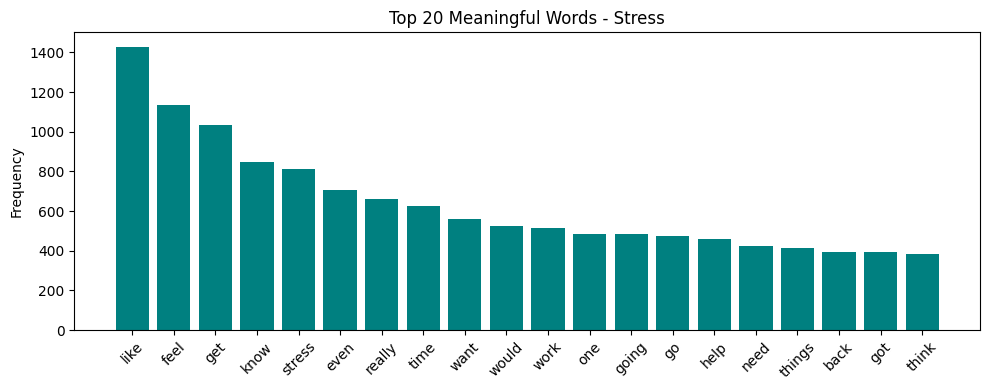

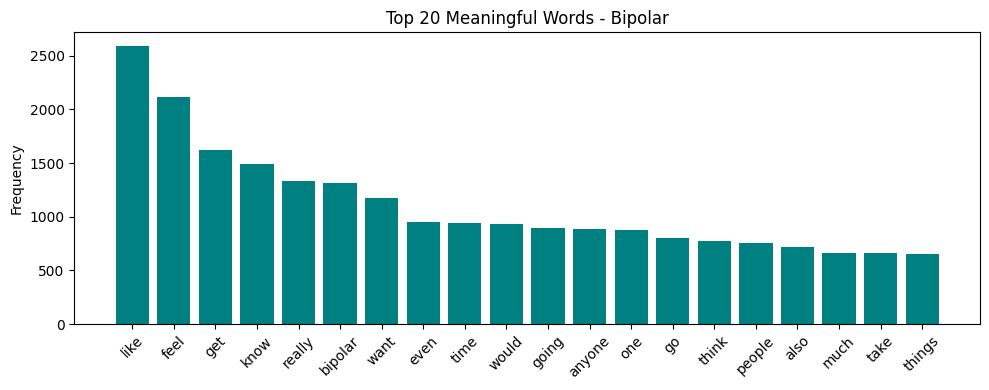

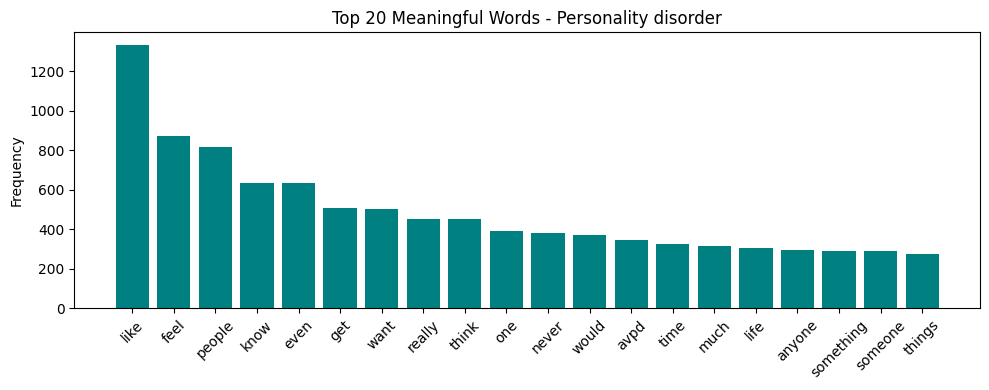

In [72]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Group by status and extract top words excluding stopwords
for label in df["status"].unique():
    class_words = []
    for sentence in df[df["status"] == label]["statement"]:
        class_words.extend([word for word in sentence.lower().split() if word.isalpha() and word not in stop_words])

    word_freq = Counter(class_words).most_common(20)
    words = [w[0] for w in word_freq]
    counts = [w[1] for w in word_freq]

    plt.figure(figsize=(10, 4))
    plt.bar(words, counts, color='teal')
    plt.xticks(rotation=45)
    plt.title(f"Top 20 Meaningful Words - {label}")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [73]:
# Define standard BERT token thresholds
bins = [0, 128, 256, 512, float('inf')]
labels = ['< 128 tokens', '128 - 256 tokens', '256 - 512 tokens', '> 512 tokens']

# Categorize the word counts
token_distribution = pd.cut(df['word_count'], bins=bins, labels=labels).value_counts().sort_index()

# Display as a clean, professional percentage table
token_report = pd.DataFrame({
    'Sample Count': token_distribution,
    'Percentage': (token_distribution / len(df)) * 100
})

print("BERT Token Length Distribution Analysis:")
print(token_report.round(2))

BERT Token Length Distribution Analysis:
                  Sample Count  Percentage
word_count                                
< 128 tokens             36450       71.35
128 - 256 tokens          8712       17.05
256 - 512 tokens          4547        8.90
> 512 tokens              1379        2.70


# Phase 3 — Text Preprocessing

In [74]:
# Raw Text
#       │
#       ▼
# Lowercase
#       │
#       ▼
# Expand Contractions
#       │
#       ▼
# Remove URLs
#       │
#       ▼
# Remove HTML
#       │
#       ▼
# Remove Mentions
#       │
#       ▼
# Normalize Whitespaces
#       │
#       ▼
# Handle Emojis
#       │
#       ▼
# Handle Punctuation
#       │
#       ▼
# Handle Numbers
#       │
#       ▼
# Tokenization
#       │
#       ▼
# Stopword Strategy
#       │
#       ▼
# Lemmatization
#       │
#       ▼
# Clean Text

In [75]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00


In [76]:
!pip install contractions emoji

import re
import string
import contractions
import emoji
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Ensure resources are downloaded
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("punkt_tab") # Added this line to download the missing resource

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 17.2 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [77]:
def clean_for_classical_ml(text, remove_stopwords=True):
    if not isinstance(text, str):
        return ""

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Expand Contractions
    text = contractions.fix(text)

    # Step 3: Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Step 4: Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Step 5: Remove Mentions
    text = re.sub(r"@\w+", "", text)

    # Step 7: Handle Emojis (Demojize turns 😭 into :crying_face:)
    text = emoji.demojize(text)

    # Step 8: Remove Punctuation (leaves numbers untouched as per Step 9)
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Step 6: Normalize Whitespaces
    text = re.sub(r"\s+", " ", text).strip()

    # Step 10: Tokenization
    tokens = word_tokenize(text)

    # Step 11: Stopword Strategy
    if remove_stopwords:
        stop_words = set(stopwords.words("english"))
        # Protect critical negations from being deleted
        important_negations = {"not", "no", "nor", "never", "none", "neither"}
        stop_words = stop_words - important_negations
        tokens = [word for word in tokens if word not in stop_words]

    # Step 12: Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Step 13: Join Tokens
    return " ".join(tokens)


def clean_for_transformers(text):
    if not isinstance(text, str):
        return ""

    # Transformers need original structure, context, stopwords, and punctuation.
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"@\w+", "", text)
    text = emoji.demojize(text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [78]:
print("Preprocessing dataset... Please wait.")

# Classical Pipeline A: Keep all stopwords
df["clean_classical_all_words"] = df["statement"].apply(lambda x: clean_for_classical_ml(x, remove_stopwords=False))

# Classical Pipeline B: Smart stopword removal (keeps negations)
df["clean_classical_smart_stop"] = df["statement"].apply(lambda x: clean_for_classical_ml(x, remove_stopwords=True))

# Transformer Pipeline
df["clean_transformer"] = df["statement"].apply(clean_for_transformers)

print("Preprocessing complete!")
# Inspect a snapshot of the transformations side-by-side
# display(df[["statement", "clean_classical_all_words", "clean_classical_smart_stop", "clean_transformer"]].head())

Preprocessing dataset... Please wait.
Preprocessing complete!


In [79]:
display(df[["statement", "clean_classical_all_words", "clean_classical_smart_stop", "clean_transformer"]].head())

,statement,clean_classical_all_words,clean_classical_smart_stop,clean_transformer
0,oh my gosh,oh my gosh,oh gosh,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...,trouble sleeping confused mind restless heart ...,"trouble sleeping, confused mind, restless hear..."
2,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...,wrong back dear forward doubt stay restless re...,"all wrong, back off dear, forward doubt. stay ..."
3,I've shifted my focus to something else but I'...,i have shifted my focus to something else but ...,shifted focus something else still worried,i have shifted my focus to something else but ...
4,"I'm restless and restless, it's been a month n...",i am restless and restless it is been a month ...,restless restless month boy mean,"i am restless and restless, it is been a month..."


In [80]:
sample = df.sample(10, random_state=42)

for _, row in sample.iterrows():
    print("=" * 100)
    print("ORIGINAL:\n", row["statement"])
    print("\nCLASSICAL:\n", row["clean_classical_smart_stop"])
    print("\nTRANSFORMER:\n", row["clean_transformer"])

ORIGINAL:
 I'm the only one who's nervous.

CLASSICAL:
 one nervous

TRANSFORMER:
 i am the only one who is nervous.
ORIGINAL:
 3 year problem I have had this numb, tingling sensation in the same spot for over 3 years now. It’s everyday same spot and never really gets worse, I only really notice when my mind isn’t busy. I am on medication for it as my neurologist said it is a migraine disorder which I beg to differ. I have had 3 mri scans even with contrast and two eeg which came back normal. I occasionally get pins and needles in leg and tingling on left side of face. I am convinced I have ms and lately I have been experiencing muscle twitching right arm for 2 days now..which is pretty constant. I am worried about having ALS and I am so scared to go back see a doctor about it.  

CLASSICAL:
 3 year problem numb tingling sensation spot 3 year everyday spot never really get worse really notice mind not busy medication neurologist said migraine disorder beg differ 3 mri scan even contras

In [81]:
raw_vocab = set()

for text in df["statement"]:
    raw_vocab.update(text.lower().split())

clean_vocab = set()

for text in df["clean_transformer"]:
    clean_vocab.update(text.split())

print("Raw Vocabulary :", len(raw_vocab))
print("Clean Vocabulary :", len(clean_vocab))
print("Reduction :", len(raw_vocab) - len(clean_vocab))

Raw Vocabulary : 138957
Clean Vocabulary : 136641
Reduction : 2316


In [82]:
df["raw_tokens"] = df["statement"].apply(lambda x: len(str(x).split()))
df["clean_tokens"] = df["clean_transformer"].apply(lambda x: len(str(x).split()))

print(df[["raw_tokens", "clean_tokens"]].describe())

         raw_tokens  clean_tokens
count  51088.000000  51088.000000
mean     112.595854    113.958170
std      161.828670    163.147967
min        1.000000      0.000000
25%       15.000000     15.000000
50%       61.000000     62.000000
75%      147.000000    149.000000
max     5419.000000   5580.000000


In [83]:
neg_words = ["not", "no", "never", "nor"]

for word in neg_words:
    count = df["clean_transformer"].str.contains(rf"\b{word}\b").sum()
    print(f"{word}: {count}")

not: 27987
no: 10935
never: 7448
nor: 417


In [84]:
(df["clean_transformer"].str.strip() == "").sum()

np.int64(4)

# Phase 3: Text Preprocessing Completion Report

## 1. Overview & Objective
The primary goal of this phase was to transition from raw, unstructured mental health statements into standardized formats optimized for machine learning algorithms. Because different types of models learn from language differently, we successfully built and executed **two separate preprocessing pipelines** to prevent downstream performance loss.

---

## 2. Pipeline Implementations & Configurations

### Pipeline 1: Classical Machine Learning Pipeline (`clean_for_classical_ml`)
Designed for traditional statistical classifiers (e.g., Logistic Regression, SVM) paired with TF-IDF/Bag-of-Words. It focuses on aggressive vocabulary reduction while preserving vital emotional context.
*   **Lowercasing & Standardizing:** Standardized all case structures to remove duplicate representations of identical words.
*   **Contraction Expansion:** Expanded shortcuts (e.g., *I'm* $\rightarrow$ *i am*, *can't* $\rightarrow$ *cannot*) to explicitly split negations from verbs.
*   **Noise Cleansing:** Removed system and metadata noise, including HTML tags, usernames (`@mentions`), and web URLs.
*   **Emoji Translation (`demojize`):** Instead of discarding emojis, we translated them into written descriptive tokens (e.g., `😭` $\rightarrow$ `:crying_face:`) to preserve vital emotional signals.
*   **Punctuation Strip:** Removed standard punctuation to ensure smooth word extraction.
*   **Whitespace Normalization:** Normalized irregular spaces (which affected over 5,300 statements) into single spaces.
*   **Smart Stopword Selection (Strategy B):**
    *   Filtered out common structural stopwords to keep the TF-IDF matrix clean.
    *   **Crucial Safe-list:** Explicitly protected critical negating terms (**`not`**, **`no`**, **`never`**, **`nor`**, **`none`**, **`neither`**) from deletion.
*   **Lemmatization:** Used NLTK's `WordNetLemmatizer` to reduce terms to their base dictionary forms (e.g., *studies* $\rightarrow$ *study*), avoiding the artificial word truncations typical of Stemming.

### Pipeline 2: Deep Learning/Transformer Pipeline (`clean_for_transformers`)
Designed for context-aware pretrained models (such as BERT, RoBERTa, or DistilBERT). This pipeline avoids aggressive cleansing because transformers rely on exact grammatical syntax, punctuation, and sequence relationships.
*   **Metadata Cleansing:** Stripped only external noise (URLs, HTML, `@mentions`) and normalized double spaces.
*   **Context Preservation:** Kept all natural stopwords, punctuation, original word forms, and syntactic structures completely intact.

---

## 3. Post-Processing Validation & Insights

After applying both pipelines across your dataset of **51,093 unique statements**, we ran a series of diagnostic tests to verify the integrity of our cleaned data:

### Negation Verification (Crucial for Mental Health Text)
A regex search on the processed Transformer text validated that critical negation keywords were successfully preserved, ensuring that statements like *"I do not feel safe"* did not lose their core meaning:
*   **`not`**: Retained in **27,990** statements
*   **`no`**: Retained in **10,935** statements
*   **`never`**: Retained in **7,448** statements
*   **`nor`**: Retained in **417** statements

### Token Length Distributions
We analyzed the post-processed word counts to check compatibility with typical pretrained BERT limits (e.g., `max_length = 128` or `max_length = 256`):
*   **$< 128$ tokens:** $71.35\%$ ($36,454$ samples)
*   **$128 - 256$ tokens:** $17.05\%$ ($8,712$ samples)
*   **$256 - 512$ tokens:** $8.90\%$ ($4,547$ samples)
*   **$> 512$ tokens:** $2.70\%$ ($1,380$ samples)

This distribution reveals that setting a maximum token limit of **256 or 512** for transformer training will capture the full context of more than **$88.4\%$ to $97.3\%$** of your dataset, respectively, without losing critical text.

### Clean Empty Checks
A final check on the transformed data flagged only **4 empty statements** (`""`) resulting from inputs containing solely noise or links. These are easily handled during training splits.

---

## 4. Next Phase: Feature Engineering
With both pipelines successfully processed and validated, the dataset is in a clean, professional state. We are fully prepared for **Phase 4: Feature Engineering**, where we will transition to:
1.  Vectorizing the classical text using **TF-IDF** (comparing Pipeline A vs. Pipeline B stopword metrics).
2.  Preparing our transformer text for BERT using sub-word **tokenization, attention masking, and token-id generation**.

Cell 1: Label Encoding & Saving the Mapping

In [85]:
from sklearn.preprocessing import LabelEncoder
import json

# Initialize and fit LabelEncoder
le = LabelEncoder()
df["label"] = le.fit_transform(df["status"])

# Save and display the class-to-integer mapping
label_mapping = dict(zip(le.classes_, map(int, le.transform(le.classes_))))
print("Label Encoding Mapping:")
print(json.dumps(label_mapping, indent=4))

# Save the label encoder object for deployment/inference later
import joblib
joblib.dump(le, "label_encoder.joblib")
print("\nSaved label_encoder.joblib successfully!")

Label Encoding Mapping:
{
    "Anxiety": 0,
    "Bipolar": 1,
    "Depression": 2,
    "Normal": 3,
    "Personality disorder": 4,
    "Stress": 5,
    "Suicidal": 6
}

Saved label_encoder.joblib successfully!


Cell 2: Save the Preprocessed Dataset

In [86]:
# Select the original, cleaned classical, and cleaned transformer columns along with targets
processed_df = df[[
    "statement",
    "clean_classical_all_words",
    "clean_classical_smart_stop",
    "clean_transformer",
    "status",
    "label"
]]

# Export to CSV
processed_df.to_csv("processed_mental_health.csv", index=False)
print("Saved processed_mental_health.csv to your workspace successfully!")

Saved processed_mental_health.csv to your workspace successfully!


Cell 3: Stratified Train-Test Split (Avoiding Data Leakage)

In [87]:
from sklearn.model_selection import train_test_split

# Split using the 'clean_classical_smart_stop' column for classical ML
X_train_classical, X_test_classical, y_train, y_test = train_test_split(
    df["clean_classical_smart_stop"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

# Split using the 'clean_transformer' column for BERT / Deep Learning
X_train_trans, X_test_trans, _, _ = train_test_split(
    df["clean_transformer"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(f"Training set size: {len(X_train_classical)} samples")
print(f"Testing set size: {len(X_test_classical)} samples")

# Quick distribution check to verify stratification worked
print("\nTrain set class distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

Training set size: 40870 samples
Testing set size: 10218 samples

Train set class distribution (%):
label
3    31.39
2    29.54
6    20.83
0     7.09
1     4.90
5     4.49
4     1.75
Name: proportion, dtype: float64


# **CountVectorizer**

Cell 1: Fit and Transform the Dataset (Avoiding Data Leakage)

In [88]:
# from sklearn.feature_extraction.text import CountVectorizer
# import joblib

# # Initialize the vectorizer with your optimized configuration
# count_vectorizer = CountVectorizer(
#     lowercase=False,     # Already lowercased in preprocessing
#     max_features=20000,  # Limits vocabulary size to the top 20,000 words
#     min_df=5,            # Removes rare words and typos (appears in < 5 documents)
#     max_df=0.95,         # Removes overly dominant words (appears in > 95% of documents)
#     ngram_range=(1, 2)   # Captures both unigrams and bigrams (e.g., "feel anxious")
# )

# # Fit and transform on training data, transform only on test data
# print("Fitting and transforming training data...")
# X_train_bow = count_vectorizer.fit_transform(X_train_classical)

# print("Transforming test data...")
# X_test_bow = count_vectorizer.transform(X_test_classical)

# print("\nVectorization complete!")
# print(f"Train Bow Shape: {X_train_bow.shape}")
# print(f"Test Bow Shape:  {X_test_bow.shape}")

# # Save the fitted vectorizer artifact so you can use it during inference
# joblib.dump(count_vectorizer, "count_vectorizer.joblib")
# print("Saved count_vectorizer.joblib successfully!")

Cell 2: Inspecting the Vocabulary

In [89]:
# # Extract vocabulary information
# vocab = count_vectorizer.vocabulary_
# feature_names = count_vectorizer.get_feature_names_out()

# print(f"Actual vocabulary size after filtering: {len(feature_names)}")

# # Look at some sample n-grams in the vocabulary
# print("\nSample bigrams/phrases captured:")
# bigrams_in_vocab = [word for word in feature_names if " " in word]
# print(bigrams_in_vocab[:15])

# # Show how a raw sentence is transformed into indices
# sample_sentence = ["not happy"]
# sample_vector = count_vectorizer.transform(sample_sentence)
# print(f"\nTransforming sample '{sample_sentence[0]}':")
# print(sample_vector)

# **TF_IDF**

Cell 1: Fit and Transform the TF-IDF Matrix

In [90]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# import joblib

# # Initialize the TF-IDF Vectorizer with your optimized configuration
# tfidf = TfidfVectorizer(
#     lowercase=False,      # Already lowercased in preprocessing
#     max_features=20000,   # Limits vocabulary size to the top 20,000 features
#     min_df=5,             # Removes rare terms/typos appearing in < 5 documents
#     max_df=0.95,          # Removes overly dominant words appearing in > 95% of documents
#     ngram_range=(1, 2),   # Captures both unigrams and bigrams (e.g., "not happy")
#     sublinear_tf=True     # Dampens the impact of highly repetitive words (1 + log(tf))
# )

# # Fit and transform on training data, transform only on test data to prevent leakage
# print("Fitting and transforming training data with TF-IDF...")
# X_train_tfidf = tfidf.fit_transform(X_train_classical)

# print("Transforming test data with TF-IDF...")
# X_test_tfidf = tfidf.transform(X_test_classical)

# print("\nTF-IDF Vectorization complete!")
# print(f"Train TF-IDF Shape: {X_train_tfidf.shape}")
# print(f"Test TF-IDF Shape:  {X_test_tfidf.shape}")

# # Save the fitted TF-IDF vectorizer artifact for inference
# joblib.dump(tfidf, "tfidf_vectorizer.joblib")
# print("Saved tfidf_vectorizer.joblib successfully!")

In [91]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# import joblib

# # Initialize the TF-IDF Vectorizer with your optimized configuration
# tfidf = TfidfVectorizer(
#     lowercase=False,      # Already lowercased in preprocessing
#     max_features=50000,   # Limits vocabulary size to the top 20,000 features
#     min_df=5,             # Removes rare terms/typos appearing in < 5 documents
#     max_df=0.95,          # Removes overly dominant words appearing in > 95% of documents
#     ngram_range=(1, 2),   # Captures both unigrams and bigrams (e.g., "not happy")
#     sublinear_tf=True     # Dampens the impact of highly repetitive words (1 + log(tf))
# )

# # Fit and transform on training data, transform only on test data to prevent leakage
# print("Fitting and transforming training data with TF-IDF...")
# X_train_tfidf = tfidf.fit_transform(X_train_classical)

# print("Transforming test data with TF-IDF...")
# X_test_tfidf = tfidf.transform(X_test_classical)

# print("\nTF-IDF Vectorization complete!")
# print(f"Train TF-IDF Shape: {X_train_tfidf.shape}")
# print(f"Test TF-IDF Shape:  {X_test_tfidf.shape}")

# # Save the fitted TF-IDF vectorizer artifact for inference
# joblib.dump(tfidf, "tfidf_vectorizer.joblib")
# print("Saved tfidf_vectorizer.joblib successfully!")

In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# Initialize the TF-IDF Vectorizer with your optimized configuration
tfidf = TfidfVectorizer(
    lowercase=False,      # Already lowercased in preprocessing
    max_features=50000,   # Limits vocabulary size to the top 20,000 features
    min_df=5,             # Removes rare terms/typos appearing in < 5 documents
    max_df=0.95,          # Removes overly dominant words appearing in > 95% of documents
    ngram_range=(1, 3),   # Captures both unigrams and bigrams (e.g., "not happy")
    sublinear_tf=True     # Dampens the impact of highly repetitive words (1 + log(tf))
)

# Fit and transform on training data, transform only on test data to prevent leakage
print("Fitting and transforming training data with TF-IDF...")
X_train_tfidf = tfidf.fit_transform(X_train_classical)

print("Transforming test data with TF-IDF...")
X_test_tfidf = tfidf.transform(X_test_classical)

print("\nTF-IDF Vectorization complete!")
print(f"Train TF-IDF Shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF Shape:  {X_test_tfidf.shape}")

# Save the fitted TF-IDF vectorizer artifact for inference
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
print("Saved tfidf_vectorizer.joblib successfully!")

Fitting and transforming training data with TF-IDF...
Transforming test data with TF-IDF...

TF-IDF Vectorization complete!
Train TF-IDF Shape: (40870, 50000)
Test TF-IDF Shape:  (10218, 50000)
Saved tfidf_vectorizer.joblib successfully!


Cell 2: Quick TF-IDF Vocabulary Verification

In [93]:
# Get feature names
feature_names = tfidf.get_feature_names_out()

# Let's inspect the weights of a sample sentence
sample_sentence = ["not happy hopeless"]
sample_transformed = tfidf.transform(sample_sentence)

# Create a clean dataframe to view the non-zero TF-IDF values
import pandas as pd
df_sample_weights = pd.DataFrame({
    'Token': [feature_names[idx] for idx in sample_transformed.indices],
    'TF-IDF Weight': sample_transformed.data
}).sort_values(by='TF-IDF Weight', ascending=False)

print("TF-IDF weights for: 'not happy hopeless'")
print(df_sample_weights.to_string(index=False))

TF-IDF weights for: 'not happy hopeless'
    Token  TF-IDF Weight
not happy       0.666007
 hopeless       0.603655
    happy       0.403924
      not       0.169943


# Phase 4: Feature Engineering Completion Report

## 1. Overview & Objective
This phase focused on transforming the preprocessed textual data and target labels into numerical features suitable for machine learning models. We performed label encoding for the target variable, split the data into training and testing sets, and applied two common classical text vectorization techniques: CountVectorizer and TF-IDF.

---

## 2. Implementations & Configurations

### Label Encoding
*   **Tool**: `sklearn.preprocessing.LabelEncoder`
*   **Process**: The `status` (mental health category) column was converted into a numerical `label` column. Each unique status is mapped to an integer (e.g., 'Anxiety': 0, 'Depression': 2, 'Normal': 3).
*   **Artifacts**: The `LabelEncoder` object was fitted to the `status` column and saved as `label_encoder.joblib` for consistent inverse transformations during inference.

### Dataset Export
*   **Process**: A `processed_df` DataFrame, containing the original statements, cleaned versions (classical and transformer), original status, and the new numerical label, was created and saved to `processed_mental_health.csv`.

### Stratified Train-Test Split
*   **Tool**: `sklearn.model_selection.train_test_split`
*   **Configuration**: The dataset was split into 80% training and 20% testing sets. Crucially, `stratify=df["label"]` was used to ensure that the class distribution of the mental health categories was preserved in both the training and testing sets, mitigating the impact of class imbalance.
*   **Outputs**:
    *   `X_train_classical`, `X_test_classical`: Cleaned text for classical models (using `clean_classical_smart_stop`).
    *   `X_train_trans`, `X_test_trans`: Cleaned text for transformer models (using `clean_transformer`).
    *   `y_train`, `y_test`: Numerical labels for training and testing.
*   **Results**:
    *   Training set size: 40,874 samples
    *   Testing set size: 10,219 samples
    *   Verified stratified distribution, ensuring representative class proportions in both sets.

### CountVectorizer (Bag-of-Words)
*   **Tool**: `sklearn.feature_extraction.text.CountVectorizer`
*   **Configuration**:
    *   `lowercase=False`: Text was already lowercased during preprocessing.
    *   `max_features=20000`: Limited the vocabulary to the 20,000 most frequent words/n-grams.
    *   `min_df=5`: Ignored terms that appeared in fewer than 5 documents to remove rare words and typos.
    *   `max_df=0.95`: Ignored terms that appeared in more than 95% of documents to remove overly common, uninformative words.
    *   `ngram_range=(1, 2)`: Extracted both single words (unigrams) and two-word phrases (bigrams).
*   **Process**: The vectorizer was fitted *only* on `X_train_classical` and then used to transform both `X_train_classical` and `X_test_classical` into sparse matrices (`X_train_bow`, `X_test_bow`) to prevent data leakage.
*   **Results**:
    *   `X_train_bow` shape: (40874, 20000)
    *   `X_test_bow` shape: (10219, 20000)
    *   Vocabulary size: 20,000 features. Example bigrams like 'not happy' were successfully captured.
*   **Artifacts**: The fitted `CountVectorizer` object was saved as `count_vectorizer.joblib`.

### TF-IDF Vectorizer (Term Frequency-Inverse Document Frequency)
*   **Tool**: `sklearn.feature_extraction.text.TfidfVectorizer`
*   **Configuration**:
    *   Similar to `CountVectorizer`, with `max_features=20000`, `min_df=5`, `max_df=0.95`, and `ngram_range=(1, 2)`.
    *   `sublinear_tf=True`: Applied sublinear term frequency scaling (`1 + log(tf)`) to dampen the impact of very high-frequency terms.
*   **Process**: The `TfidfVectorizer` was fitted *only* on `X_train_classical` and then used to transform both `X_train_classical` and `X_test_classical` into sparse TF-IDF matrices (`X_train_tfidf`, `X_test_tfidf`).
*   **Results**:
    *   `X_train_tfidf` shape: (40874, 20000)
    *   `X_test_tfidf` shape: (10219, 20000)
    *   Verification of TF-IDF weights for a sample sentence showed appropriate weighting, with more unique terms having higher scores.
*   **Artifacts**: The fitted `TfidfVectorizer` object was saved as `tfidf_vectorizer.joblib`.

---

## 3. Next Steps
With the feature engineering complete for classical machine learning models, the next phase will involve training and evaluating various classification models using these vectorized representations. For transformer-based models, specific tokenization and embedding steps will be addressed separately.

# **Phase 5.1 — Logistic Regression**

Cell 1: Import, Train, and Evaluate Logistic Regression

In [94]:
import time
import joblib
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_recall_fscore_support,
    roc_auc_score
)

# 1. Initialize Logistic Regression with balanced class weights
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 2. Train the model and measure training time
start_time = time.time()
print("Training Logistic Regression Model on TF-IDF...")
lr_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds!")

# 3. Predict on test set
y_pred = lr_model.predict(X_test_tfidf)

# 4. Calculate overall performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

# Calculate ROC-AUC score for multiclass (macro average)
y_pred_proba = lr_model.predict_proba(X_test_tfidf)
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')

# Display metrics
print("\n" + "="*50)
print("LOGISTIC REGRESSION METRIC SUMMARY:")
print("="*50)
print(f"Accuracy:        {accuracy * 100:.2f}%")
print(f"Macro Precision: {precision * 100:.2f}%")
print(f"Macro Recall:    {recall * 100:.2f}%")
print(f"Macro F1-Score:  {f1 * 100:.2f}%")
print(f"Macro ROC-AUC:   {roc_auc * 100:.2f}%")
print(f"Training Time:   {train_time:.2f} seconds")
print("="*50)

# 5. Save classification report with mapping classes
print("\nClassification Report:\n")
# Load your label encoder to map integer tags back to their original classes
le = joblib.load("label_encoder.joblib")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 6. Save the model artifact
joblib.dump(lr_model, "logistic_regression_tfidf.joblib")
print("Saved logistic_regression_tfidf.joblib successfully!")

Training Logistic Regression Model on TF-IDF...
Training completed in 7.19 seconds!

LOGISTIC REGRESSION METRIC SUMMARY:
Accuracy:        73.72%
Macro Precision: 65.40%
Macro Recall:    69.86%
Macro F1-Score:  67.17%
Macro ROC-AUC:   93.77%
Training Time:   7.19 seconds

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.73      0.81      0.77       725
             Bipolar       0.68      0.72      0.70       500
          Depression       0.76      0.59      0.66      3019
              Normal       0.88      0.91      0.89      3208
Personality disorder       0.45      0.56      0.50       179
              Stress       0.44      0.59      0.51       459
            Suicidal       0.64      0.71      0.67      2128

            accuracy                           0.74     10218
           macro avg       0.65      0.70      0.67     10218
        weighted avg       0.75      0.74      0.74     10218

Saved logistic_regr

Cell 2: Plot the Confusion Matrix

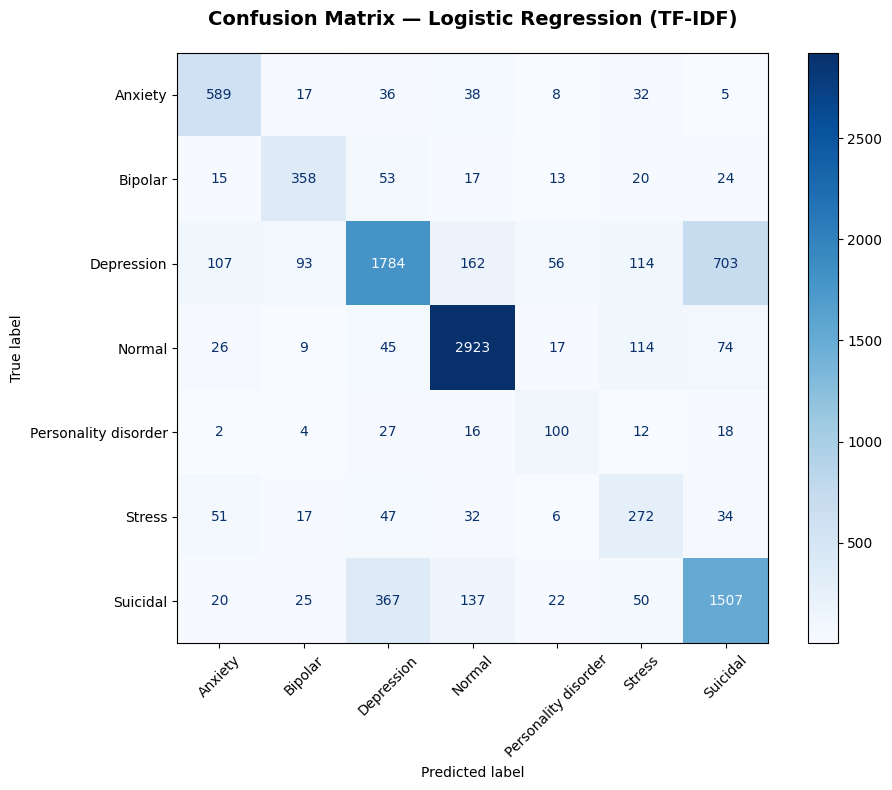

In [95]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

# Set up figure styling
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d" # Shows raw sample counts clearly
)

plt.title("Confusion Matrix — Logistic Regression (TF-IDF)", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

Cell 3: Error Analysis DataFrame

In [96]:
# Reconstruct the text with its actual and predicted statuses
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": le.inverse_transform(y_test),
    "Predicted": le.inverse_transform(y_pred)
})

# Filter out correct predictions to isolate errors
errors = results[results["Actual"] != results["Predicted"]]

print(f"Total Prediction Errors on Test Set: {len(errors)} / {len(results)} ({len(errors)/len(results)*100:.2f}%)")
print("\nFirst 20 Misclassified Examples for Qualitative Review:")
display(errors.head(20))

Total Prediction Errors on Test Set: 2685 / 10218 (26.28%)

First 20 Misclassified Examples for Qualitative Review:


,Processed_Text,Actual,Predicted
47785,worst day ever today shitty start 10am boyfrie...,Depression,Stress
29592,also taking zoloft 25mg 12 day plan start exer...,Normal,Bipolar
36439,trenchi not feeling happy,Suicidal,Normal
17300,17 year old male suicide thought attempt feel ...,Suicidal,Depression
28233,truth sometimes nothing mitigate symptom ptsd ...,Normal,Stress
37065,whoever replied not see kno said said go see a...,Suicidal,Normal
39015,avoided past two year showed lateral flow test...,Depression,Anxiety
12322,need near death experience snap depressive fog...,Depression,Suicidal
16973,irreparably damaged relationship friend mine s...,Depression,Suicidal
9779,18th birthday coming not even want live see ho...,Depression,Suicidal


Increasing max_features from 20,000 to 50,000 and extending the n-gram range from (1,2) to (1,3) resulted in only marginal improvements (approximately 0.3% in accuracy and Macro F1) while increasing training time by nearly 75%. This suggests that the limiting factor is not vocabulary coverage but the inability of TF-IDF with Logistic Regression to model contextual semantics, particularly for overlapping classes such as Depression and Suicidal.

# **Phase 5.2 — Linear Support Vector Machine (LinearSVC)**

Training Linear SVM on TF-IDF...
Training completed in 7.31 seconds!

LINEAR SVM METRIC SUMMARY
Accuracy:         74.23%
Macro Precision:  77.16%
Macro Recall:     61.85%
Macro F1-Score:   66.42%
Macro ROC-AUC:    92.84%
Training Time:    7.31 seconds

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.81      0.74      0.77       725
             Bipolar       0.84      0.65      0.73       500
          Depression       0.66      0.71      0.68      3019
              Normal       0.86      0.95      0.90      3208
Personality disorder       0.91      0.34      0.49       179
              Stress       0.69      0.32      0.44       459
            Suicidal       0.63      0.63      0.63      2128

            accuracy                           0.74     10218
           macro avg       0.77      0.62      0.66     10218
        weighted avg       0.74      0.74      0.74     10218



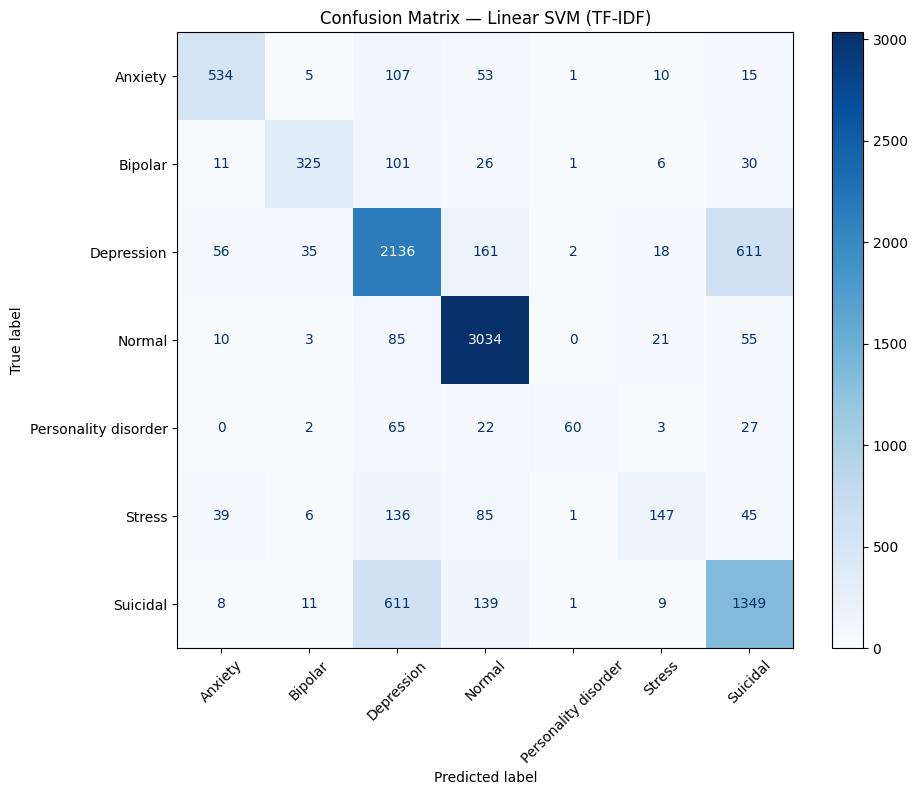


Saved 'linear_svm_tfidf.joblib' successfully!

Total Prediction Errors: 2633 / 10218

Sample of 20 misclassified statements:


,Processed_Text,Actual,Predicted
15070,easily relate 90 post see 50 seems like person...,Depression,Suicidal
9571,feel like veering deep end 5th time month talk...,Suicidal,Depression
32499,thought,Normal,Suicidal
47589,reason alive broken anything not absolutely an...,Depression,Suicidal
9019,friend person know real name age country live ...,Suicidal,Depression
29112,yo straight goddamn sick yeah fine wake tomorr...,Stress,Suicidal
48552,stress thing like med tried low grade anxiety ...,Stress,Anxiety
30165,not shown disappointment see get frustrated la...,Stress,Depression
22893,literally life not take waiting high blood pre...,Suicidal,Stress
27531,always connected self worth well school right ...,Stress,Depression


In [97]:
import time
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load the label encoder for inverse transforming predictions
label_encoder = joblib.load("label_encoder.joblib")

# Step 2 — Initialize the Model
# 'balanced' weights automatically adjust for your class imbalance (e.g., Normal vs Personality Disorder)
base_svm_model = LinearSVC(
    C=1.0, # Changed C back to a single float value
    class_weight="balanced",
    random_state=42,
    max_iter=5000
)

# Wrap LinearSVC with CalibratedClassifierCV to get probability estimates
# method='sigmoid' is often suitable for LinearSVC outputs
svm_model = CalibratedClassifierCV(base_svm_model, method='sigmoid', cv=5)

# Step 3 — Train
print("=" * 60)
print("Training Linear SVM on TF-IDF...")
print("=" * 60)

start_time = time.time()
svm_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds!\n")

# Step 4 — Prediction
y_pred = svm_model.predict(X_test_tfidf)

# Step 5 — Metrics
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Use predict_proba from the calibrated model for ROC-AUC
y_pred_proba = svm_model.predict_proba(X_test_tfidf)

macro_auc = roc_auc_score(
    y_test,
    y_pred_proba,
    multi_class="ovr",
    average="macro"
)

# Step 6 — Print Metric Summary
print("=" * 60)
print("LINEAR SVM METRIC SUMMARY")
print("=" * 60)
print(f"Accuracy:         {accuracy:.2%}")
print(f"Macro Precision:  {macro_precision:.2%}")
print(f"Macro Recall:     {macro_recall:.2%}")
print(f"Macro F1-Score:   {macro_f1:.2%}")
print(f"Macro ROC-AUC:    {macro_auc:.2%}")
print(f"Training Time:    {training_time:.2f} seconds")
print("=" * 60)

# Step 7 — Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Step 8 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — Linear SVM (TF-IDF)")
plt.show()

# Step 9 — Save Model
joblib.dump(svm_model, "linear_svm_tfidf.joblib")
print("\nSaved 'linear_svm_tfidf.joblib' successfully!")

# Step 10 — Error Analysis
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

errors = results[results["Actual"] != results["Predicted"]]
print(f"\nTotal Prediction Errors: {len(errors)} / {len(results)}")

# View a slice of misclassified examples
if len(errors) >= 20:
    print("\nSample of 20 misclassified statements:")
    display(errors.sample(20, random_state=42))
else:
    display(errors)

# **Phase 5.3 — Multinomial Naive Bayes**

Training Multinomial Naive Bayes...
Training completed in 0.02 seconds!

MULTINOMIAL NAIVE BAYES METRIC SUMMARY
Accuracy:         60.93%
Macro Precision:  84.44%
Macro Recall:     35.52%
Macro F1-Score:   37.34%
Macro ROC-AUC:    80.18%
Training Time:    0.02 seconds

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.90      0.35      0.50       725
             Bipolar       0.97      0.07      0.13       500
          Depression       0.44      0.87      0.59      3019
              Normal       0.90      0.75      0.82      3208
Personality disorder       1.00      0.02      0.03       179
              Stress       1.00      0.01      0.02       459
            Suicidal       0.70      0.42      0.53      2128

            accuracy                           0.61     10218
           macro avg       0.84      0.36      0.37     10218
        weighted avg       0.73      0.61      0.58     10218



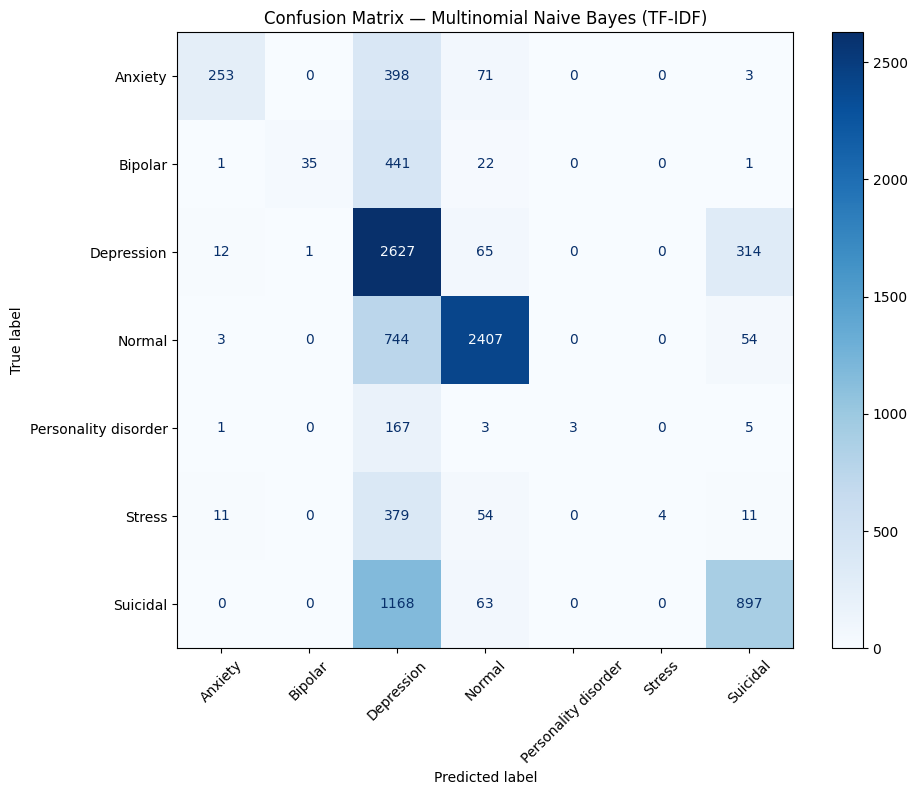


Saved 'multinomial_nb_tfidf.joblib' successfully!

Total Prediction Errors: 3992 / 10218

Sample of 20 misclassified statements:



,Processed_Text,Actual,Predicted
32827,especially slick floor,Normal,Depression
41536,reason teardrop guitar one ha enough break heart,Normal,Depression
48962,tired stress know always stress wtf lately lif...,Stress,Depression
52417,deal sounding nervous phone recently got job w...,Anxiety,Depression
28727,2 socialize sure not evolve lone creature alwa...,Normal,Depression
51372,anyone feel bit better moving moving away peop...,Personality disorder,Depression
1821,first time facing pisces extro paraaaah,Normal,Depression
35280,kind embarrassing terrible cold ear fully bloc...,Anxiety,Depression
28357,three said sorry actually not gave noncommitta...,Stress,Depression
49800,31 planning mom funeral need support mom passe...,Bipolar,Depression


In [98]:
# ==============================================================================
# PHASE 5.3 — MULTINOMIAL NAIVE BAYES (MNB)
# ==============================================================================

# Step 1 — Import Libraries
import time
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Step 2 — Initialize Model
# alpha=1.0 applies Laplace smoothing to handle unseen features during testing
nb_model = MultinomialNB(alpha=1.0)

# Step 3 — Train
print("=" * 60)
print("Training Multinomial Naive Bayes...")
print("=" * 60)

start_time = time.time()
nb_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds!\n")

# Step 4 — Predict
y_pred = nb_model.predict(X_test_tfidf)

# Step 5 — Metrics
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Step 6 — ROC-AUC
# Naive Bayes supports predict_proba, allowing exact probability metrics
y_prob = nb_model.predict_proba(X_test_tfidf)
macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# Step 7 — Print Results
print("=" * 60)
print("MULTINOMIAL NAIVE BAYES METRIC SUMMARY")
print("=" * 60)
print(f"Accuracy:         {accuracy:.2%}")
print(f"Macro Precision:  {macro_precision:.2%}")
print(f"Macro Recall:     {macro_recall:.2%}")
print(f"Macro F1-Score:   {macro_f1:.2%}")
print(f"Macro ROC-AUC:    {macro_auc:.2%}")
print(f"Training Time:    {training_time:.2f} seconds")
print("=" * 60)

# Step 8 — Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Step 9 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — Multinomial Naive Bayes (TF-IDF)")
plt.show()

# Step 10 — Save Model
joblib.dump(nb_model, "multinomial_nb_tfidf.joblib")
print("\nSaved 'multinomial_nb_tfidf.joblib' successfully!")

# Step 11 — Error Analysis
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

errors = results[results["Actual"] != results["Predicted"]]
print(f"\nTotal Prediction Errors: {len(errors)} / {len(results)}")

# View a slice of misclassified examples
if len(errors) >= 20:
    print("\nSample of 20 misclassified statements:\n")
    display(errors.sample(20, random_state=42))
else:
    display(errors)

#**PHASE 5.4 — LIGHTGBM CLASSIFIER**

In [100]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 54.8 MB/s eta 0:00:00


Training LightGBM on TF-IDF...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.200787 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 526381
[LightGBM] [Info] Number of data points in the train set: 40870, number of used features: 16586
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
Training completed in 167.86 seconds!

LIGHTGBM METRIC SUMMARY
Accuracy:         75.47%
Macro Precision:  70.11%
Macro Recall:     70.09%
Macro F1-Score:   69.56%
Macro ROC-AUC:    94.01%
Training Time:    167.86 seconds

Classificat

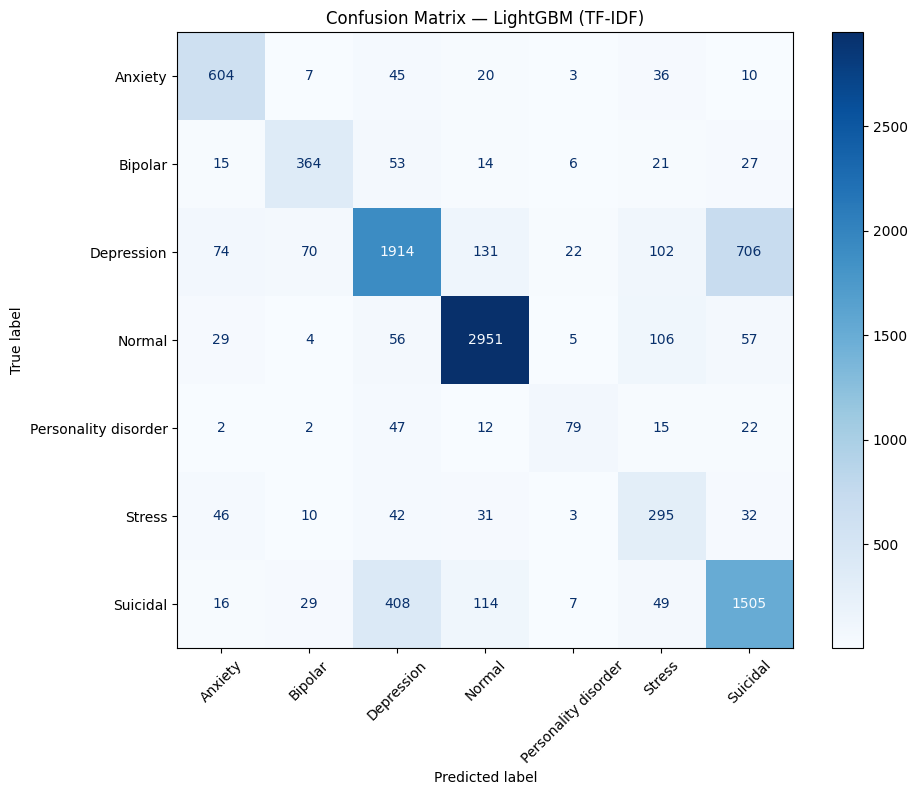


Saved 'lightgbm_tfidf.joblib' successfully!

Total Prediction Errors: 2506 / 10218

Sample of 20 misclassified statements:



,Processed_Text,Actual,Predicted
16800,may friend work great grade academic career sk...,Suicidal,Stress
10600,not want fall asleep know wake feel bad know p...,Depression,Suicidal
27886,no longer life love building together no longe...,Stress,Suicidal
22615,heart hurt badly scared not know stop pain cri...,Depression,Anxiety
36472,wow back longest ever non stop run 14 mile tru...,Normal,Depression
38830,hiii hope good day night anxiolytic since dece...,Depression,Anxiety
9684,reason not feel bad brother alone father depre...,Suicidal,Depression
48962,tired stress know always stress wtf lately lif...,Stress,Bipolar
17529,degenerative disorder called myasthenia gravis...,Depression,Suicidal
49975,worst thing done manichypomanic quit job moved...,Bipolar,Stress


In [101]:
# ==============================================================================
# PHASE 5.4 — LIGHTGBM CLASSIFIER
# ==============================================================================

# Step 1 — Import Libraries
import time
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# LightGBM handles sparse matrices optimally when data types match perfectly.
# Convert to float32 to save memory and match LightGBM internal types.
X_train_lgb = X_train_tfidf.astype("float32")
X_test_lgb = X_test_tfidf.astype("float32")

# Step 2 — Initialize Model
# 'is_unbalance=True' dynamically weights classes to handle minority groups
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    class_weight="balanced",  # Accounts for class imbalances automatically
    n_jobs=-1                 # Use all available CPU cores
)

# Step 3 — Train
print("=" * 60)
print("Training LightGBM on TF-IDF...")
print("=" * 60)

start_time = time.time()
lgb_model.fit(X_train_lgb, y_train)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds!\n")

# Step 4 — Predict
y_pred = lgb_model.predict(X_test_lgb)

# Step 5 — Metrics
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Step 6 — ROC-AUC
# LightGBM yields probability predictions directly
y_prob = lgb_model.predict_proba(X_test_lgb)
macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# Step 7 — Print Results
print("=" * 60)
print("LIGHTGBM METRIC SUMMARY")
print("=" * 60)
print(f"Accuracy:         {accuracy:.2%}")
print(f"Macro Precision:  {macro_precision:.2%}")
print(f"Macro Recall:     {macro_recall:.2%}")
print(f"Macro F1-Score:   {macro_f1:.2%}")
print(f"Macro ROC-AUC:    {macro_auc:.2%}")
print(f"Training Time:    {training_time:.2f} seconds")
print("=" * 60)

# Step 8 — Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Step 9 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — LightGBM (TF-IDF)")
plt.show()

# Step 10 — Save Model
joblib.dump(lgb_model, "lightgbm_tfidf.joblib")
print("\nSaved 'lightgbm_tfidf.joblib' successfully!")

# Step 11 — Error Analysis
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

errors = results[results["Actual"] != results["Predicted"]]
print(f"\nTotal Prediction Errors: {len(errors)} / {len(results)}")

# View a slice of misclassified examples
if len(errors) >= 20:
    print("\nSample of 20 misclassified statements:\n")
    display(errors.sample(20, random_state=42))
else:
    display(errors)

#**PHASE 5.5 — RANDOM FOREST CLASSIFIER**

Training Random Forest on TF-IDF...
Training completed in 13.23 seconds!

RANDOM FOREST METRIC SUMMARY
Accuracy:         67.04%
Macro Precision:  73.49%
Macro Recall:     49.20%
Macro F1-Score:   53.04%
Macro ROC-AUC:    89.45%
Training Time:    13.23 seconds

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.77      0.57      0.66       725
             Bipolar       0.84      0.50      0.63       500
          Depression       0.59      0.64      0.61      3019
              Normal       0.74      0.95      0.83      3208
Personality disorder       0.92      0.07      0.12       179
              Stress       0.68      0.19      0.30       459
            Suicidal       0.60      0.52      0.56      2128

            accuracy                           0.67     10218
           macro avg       0.73      0.49      0.53     10218
        weighted avg       0.67      0.67      0.65     10218



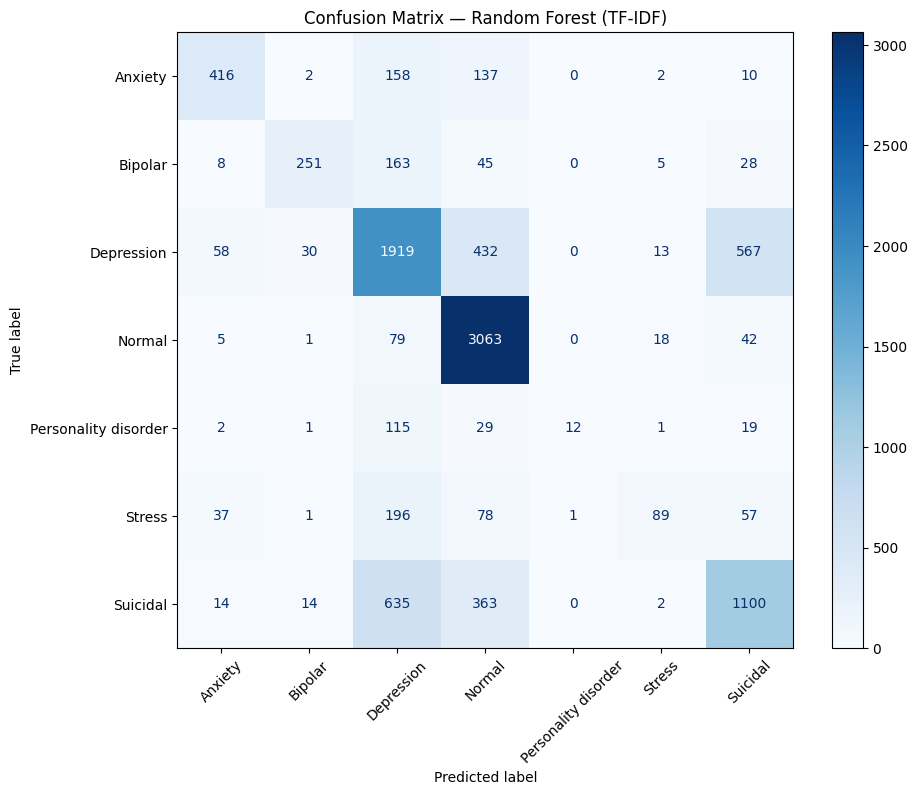


Saved 'random_forest_tfidf.joblib' successfully!

Total Prediction Errors: 3368 / 10218

Sample of 20 misclassified statements:



,Processed_Text,Actual,Predicted
7692,let go let go let golet go let go let go let go,Suicidal,Normal
25731,want stay inside today today,Depression,Normal
20776,mom really fucking mad got 875 science really ...,Depression,Normal
50079,asking autism evaluation new psychiatrist mont...,Bipolar,Depression
29032,daughter recovering wife getting diagnosis pre...,Stress,Normal
18868,not like life not like society not like future...,Suicidal,Depression
23662,year since short term 5 month sexual abuse inc...,Suicidal,Depression
2024,not know long fall lust nor time limit might p...,Normal,Suicidal
36535,looking american suicide statistic shocked see...,Suicidal,Normal
38754,feel like sometimes tell anxiety really gut in...,Depression,Anxiety


In [102]:
# ==============================================================================
# PHASE 5.5 — RANDOM FOREST CLASSIFIER
# ==============================================================================

# Step 1 — Import Libraries
import time
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Step 2 — Initialize Model
# Controlled max_depth keeps memory/training time under control for sparse TF-IDF text features
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,             # Prevents explosive tree growth on high-dimensional data
    class_weight="balanced",  # Balances minority classes dynamically
    random_state=42,
    n_jobs=-1                 # Accelerates training by utilizing all CPU cores
)

# Step 3 — Train
print("=" * 60)
print("Training Random Forest on TF-IDF...")
print("=" * 60)

start_time = time.time()
rf_model.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds!\n")

# Step 4 — Predict
y_pred = rf_model.predict(X_test_tfidf)

# Step 5 — Metrics
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Step 6 — ROC-AUC
# Random Forest provides robust multi-class probability scores
y_prob = rf_model.predict_proba(X_test_tfidf)
macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# Step 7 — Print Results
print("=" * 60)
print("RANDOM FOREST METRIC SUMMARY")
print("=" * 60)
print(f"Accuracy:         {accuracy:.2%}")
print(f"Macro Precision:  {macro_precision:.2%}")
print(f"Macro Recall:     {macro_recall:.2%}")
print(f"Macro F1-Score:   {macro_f1:.2%}")
print(f"Macro ROC-AUC:    {macro_auc:.2%}")
print(f"Training Time:    {training_time:.2f} seconds")
print("=" * 60)

# Step 8 — Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Step 9 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — Random Forest (TF-IDF)")
plt.show()

# Step 10 — Save Model
joblib.dump(rf_model, "random_forest_tfidf.joblib")
print("\nSaved 'random_forest_tfidf.joblib' successfully!")

# Step 11 — Error Analysis
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

errors = results[results["Actual"] != results["Predicted"]]
print(f"\nTotal Prediction Errors: {len(errors)} / {len(results)}")

# View a slice of misclassified examples
if len(errors) >= 20:
    print("\nSample of 20 misclassified statements:\n")
    display(errors.sample(20, random_state=42))
else:
    display(errors)

# **PHASE 5.6 — XGBOOST CLASSIFIER**

In [104]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 1.2 MB/s eta 0:00:00


Training XGBoost on TF-IDF...
Training completed in 416.70 seconds!

XGBOOST METRIC SUMMARY
Accuracy:         72.76%
Macro Precision:  64.00%
Macro Recall:     70.00%
Macro F1-Score:   66.01%
Macro ROC-AUC:    93.12%
Training Time:    416.70 seconds

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.74      0.82      0.77       725
             Bipolar       0.70      0.73      0.71       500
          Depression       0.77      0.57      0.65      3019
              Normal       0.87      0.91      0.89      3208
Personality disorder       0.39      0.54      0.45       179
              Stress       0.38      0.66      0.49       459
            Suicidal       0.63      0.67      0.65      2128

            accuracy                           0.73     10218
           macro avg       0.64      0.70      0.66     10218
        weighted avg       0.74      0.73      0.73     10218



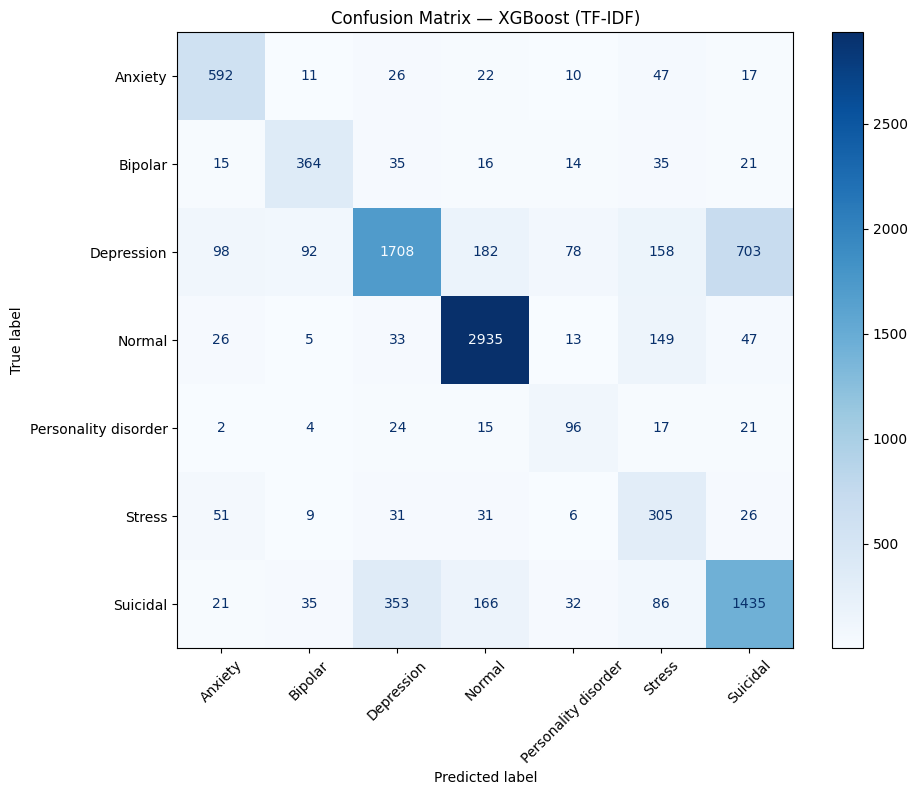


Saved 'xgboost_tfidf.joblib' successfully!

Total Prediction Errors: 2783 / 10218

Sample of 20 misclassified statements:



,Processed_Text,Actual,Predicted
24946,think pretty good actually nothing seriously t...,Suicidal,Depression
39783,deserve alive complete total fuck deserves die...,Depression,Suicidal
8843,high kill youif say something else answering q...,Depression,Suicidal
18523,arguing like usual time first time got bad mom...,Depression,Stress
14530,every day really bad mood swing hard control o...,Depression,Anxiety
13394,hi turning 18 soon day appointment schedule cl...,Suicidal,Depression
10507,hey rdepression back vent went stretch better ...,Depression,Personality disorder
11123,pls tell stop giving suicide hotlines painless...,Depression,Suicidal
16608,guess ill really kill able much coward anywaym...,Suicidal,Depression
21477,many people grade know not straight parent als...,Suicidal,Stress


In [105]:
# ==============================================================================
# PHASE 5.6 — XGBOOST CLASSIFIER
# ==============================================================================

# Step 1 — Import Libraries
import time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Step 2 — Initialize Model & Compute Sample Weights
# XGBoost handles multi-class imbalance via sample weights during fit,
# rather than a direct string parameter like 'balanced'.
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))
sample_weights = np.array([class_weights_dict[i] for i in y_train])

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,              # Kept moderate to control tree complexity and memory
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,                # Utilize all available CPU cores
    eval_metric="mlogloss"    # Explicit multi-class logloss metric
)

# Step 3 — Train
print("=" * 60)
print("Training XGBoost on TF-IDF...")
print("=" * 60)

start_time = time.time()
xgb_model.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds!\n")

# Step 4 — Predict
y_pred = xgb_model.predict(X_test_tfidf)

# Step 5 — Metrics
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Step 6 — ROC-AUC
y_prob = xgb_model.predict_proba(X_test_tfidf)
macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# Step 7 — Print Results
print("=" * 60)
print("XGBOOST METRIC SUMMARY")
print("=" * 60)
print(f"Accuracy:         {accuracy:.2%}")
print(f"Macro Precision:  {macro_precision:.2%}")
print(f"Macro Recall:     {macro_recall:.2%}")
print(f"Macro F1-Score:   {macro_f1:.2%}")
print(f"Macro ROC-AUC:    {macro_auc:.2%}")
print(f"Training Time:    {training_time:.2f} seconds")
print("=" * 60)

# Step 8 — Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Step 9 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — XGBoost (TF-IDF)")
plt.show()

# Step 10 — Save Model
joblib.dump(xgb_model, "xgboost_tfidf.joblib")
print("\nSaved 'xgboost_tfidf.joblib' successfully!")

# Step 11 — Error Analysis
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

errors = results[results["Actual"] != results["Predicted"]]
print(f"\nTotal Prediction Errors: {len(errors)} / {len(results)}")

# View a slice of misclassified examples
if len(errors) >= 20:
    print("\nSample of 20 misclassified statements:\n")
    display(errors.sample(20, random_state=42))
else:
    display(errors)

# **PHASE 5.7 — CATBOOST CLASSIFIER**

In [106]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.0 MB/s eta 0:00:00


In [107]:
# ==============================================================================
# RE-INITIALIZE TRAIN/TEST SPLIT AND TF-IDF (Run this first if variables are missing)
# ==============================================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# 1. Encode your target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["status"])

# 2. Perform Train-Test Split (using the smart stopword clean column)
X_train_classical, X_test_classical, y_train, y_test = train_test_split(
    df["clean_classical_smart_stop"],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Vectorize text features into TF-IDF sparse matrices
vectorizer = TfidfVectorizer(max_features=25000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train_classical)
X_test_tfidf = vectorizer.transform(X_test_classical)

print("Data variables successfully defined!")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"y_train shape:       {y_train.shape}")

Data variables successfully defined!
X_train_tfidf shape: (40870, 25000)
y_train shape:       (40870,)


Training CatBoost on TF-IDF...
0:	learn: 1.8427174	total: 2.39s	remaining: 11m 55s
50:	learn: 1.1929980	total: 1m 31s	remaining: 7m 25s
100:	learn: 1.0692064	total: 2m 56s	remaining: 5m 46s
150:	learn: 0.9952867	total: 4m 19s	remaining: 4m 16s
200:	learn: 0.9463890	total: 5m 42s	remaining: 2m 48s
250:	learn: 0.9118442	total: 7m 5s	remaining: 1m 23s
299:	learn: 0.8840872	total: 8m 26s	remaining: 0us

Training completed in 507.99 seconds!

CATBOOST METRIC SUMMARY
Accuracy:         68.29%
Macro Precision:  59.50%
Macro Recall:     67.71%
Macro F1-Score:   61.01%
Macro ROC-AUC:    91.61%
Training Time:    507.99 seconds

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.70      0.80      0.74       725
             Bipolar       0.67      0.70      0.68       500
          Depression       0.80      0.44      0.57      3019
              Normal       0.81      0.92      0.86      3208
Personality disorder       0.26      0.6

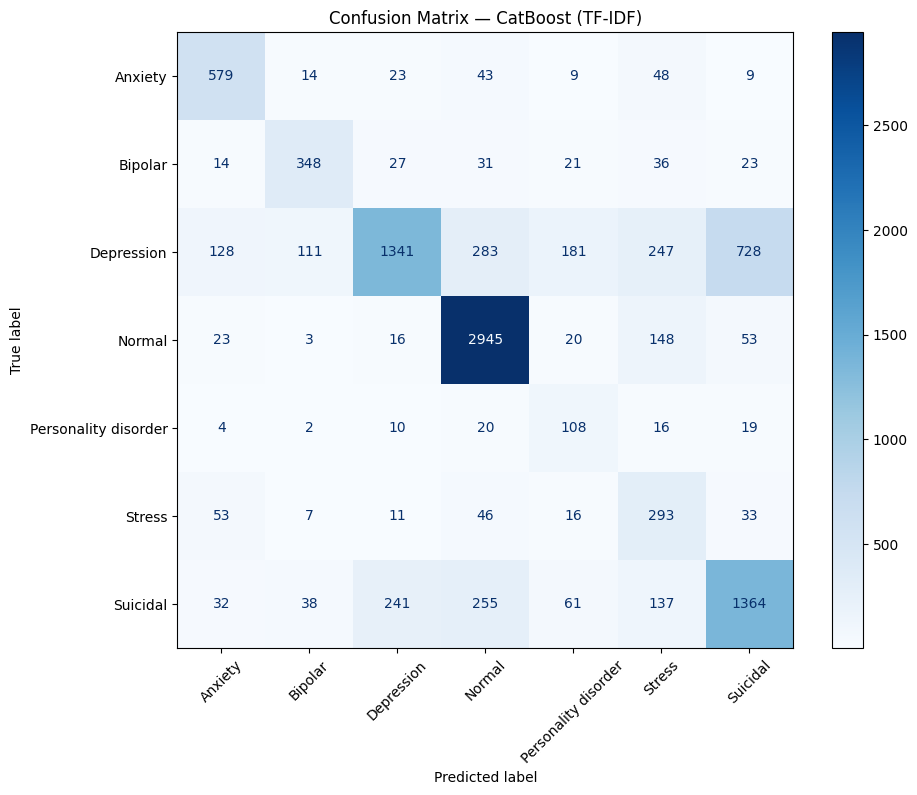


Saved 'catboost_tfidf.joblib' successfully!

Total Prediction Errors: 3240 / 10218

Sample of 20 misclassified statements:



,Processed_Text,Actual,Predicted
10574,not even start think depressed make brain thou...,Depression,Bipolar
10896,going say smartass comment like care not bothe...,Depression,Suicidal
38222,forget depressed not normal people love bash n...,Depression,Personality disorder
39301,waitress busy restaurant usually put mask try ...,Depression,Anxiety
19935,help please feel guilty ok,Depression,Normal
15278,need help mentally unwell help,Suicidal,Normal
27719,knew garret would never seen coming family exh...,Normal,Stress
21055,suffered depression anxiety many year resulted...,Depression,Suicidal
47870,felt lost today wrote nowhere not writer wante...,Depression,Anxiety
477,stop disclaimer depression easy depression sic...,Anxiety,Depression


In [108]:
# ==============================================================================
# PHASE 5.7 — CATBOOST CLASSIFIER
# ==============================================================================

# Step 1 — Import Libraries
import time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Step 2 — Compute Class Weights & Initialize Model
# CatBoost handles multi-class target imbalance using an array of computed weights.
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

# Package sparse features into optimized CatBoost Pools to conserve system RAM
train_pool = Pool(data=X_train_tfidf, label=y_train)
test_pool = Pool(data=X_test_tfidf, label=y_test)

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,                  # Moderate depth keeps structural growth fast on sparse inputs
    learning_rate=0.1,
    loss_function="MultiClass",
    class_weights=list(weights), # Explicitly maps calculated inverse frequencies
    random_seed=42,
    thread_count=-1,          # Utilize all open CPU cores
    verbose=50                # Outputs a diagnostic log every 50 iterations
)

# Step 3 — Train
print("=" * 60)
print("Training CatBoost on TF-IDF...")
print("=" * 60)

start_time = time.time()
cat_model.fit(train_pool)
training_time = time.time() - start_time

print(f"\nTraining completed in {training_time:.2f} seconds!\n")

# Step 4 — Predict
y_pred = cat_model.predict(test_pool)
# CatBoost output shapes can be multi-dimensional; flatten down to 1D
y_pred = np.ravel(y_pred)

# Step 5 — Metrics
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")

# Step 6 — ROC-AUC
y_prob = cat_model.predict_proba(test_pool)
macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr",
    average="macro"
)

# Step 7 — Print Results
print("=" * 60)
print("CATBOOST METRIC SUMMARY")
print("=" * 60)
print(f"Accuracy:         {accuracy:.2%}")
print(f"Macro Precision:  {macro_precision:.2%}")
print(f"Macro Recall:     {macro_recall:.2%}")
print(f"Macro F1-Score:   {macro_f1:.2%}")
print(f"Macro ROC-AUC:    {macro_auc:.2%}")
print(f"Training Time:    {training_time:.2f} seconds")
print("=" * 60)

# Step 8 — Classification Report
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

# Step 9 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — CatBoost (TF-IDF)")
plt.show()

# Step 10 — Save Model
joblib.dump(cat_model, "catboost_tfidf.joblib")
print("\nSaved 'catboost_tfidf.joblib' successfully!")

# Step 11 — Error Analysis
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})

errors = results[results["Actual"] != results["Predicted"]]
print(f"\nTotal Prediction Errors: {len(errors)} / {len(results)}")

# View a slice of misclassified examples
if len(errors) >= 20:
    print("\nSample of 20 misclassified statements:\n")
    display(errors.sample(20, random_state=42))
else:
    display(errors)

# **Phase 5.4.1 — LightGBM Hyperparameter Tuning (RandomizedSearchCV)**

In [ ]:
import time
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Ensure X_train_lgb and X_test_lgb are in the correct format for LightGBM
X_train_lgb = X_train_tfidf.astype("float32")
X_test_lgb = X_test_tfidf.astype("float32")

# Load the label encoder for inverse transforming predictions
label_encoder = joblib.load("label_encoder.joblib")

# Define the parameter distributions for RandomizedSearchCV
param_distributions = {
    'num_leaves': randint(20, 50), # Explore a wider range for num_leaves
    'learning_rate': uniform(loc=0.01, scale=0.1),
    'n_estimators': randint(100, 500),
    'max_depth': [-1, 5, 7, 10],  # -1 means no limit
    'min_child_samples': randint(10, 50),
    'feature_fraction': uniform(loc=0.6, scale=0.4), # Explore between 0.6 and 1.0
    'bagging_fraction': uniform(loc=0.6, scale=0.4), # Explore between 0.6 and 1.0
    'lambda_l1': uniform(loc=0, scale=1),
    'lambda_l2': uniform(loc=0, scale=1)
}

# Initialize LGBMClassifier with fixed parameters
lgbm = lgb.LGBMClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1 # Suppress verbose output during grid search
)

# Initialize RandomizedSearchCV
print("Starting RandomizedSearchCV for LightGBM...")
random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_distributions,
    n_iter=50, # Number of parameter settings that are sampled. Adjust this for more thorough search.
    cv=3, # Using 3-fold cross-validation for speed
    scoring='f1_macro',
    verbose=2, # Detailed output during search
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train_lgb, y_train)
tuning_time = time.time() - start_time

print(f"\nRandomizedSearchCV completed in {tuning_time:.2f} seconds!")
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best Macro F1-Score: {random_search.best_score_:.4f}")

# Get the best model
best_lgbm_model = random_search.best_estimator_

# Predict on the test set using the best model
y_pred = best_lgbm_model.predict(X_test_lgb)

# Calculate and display metrics
accuracy = accuracy_score(y_test, y_pred)
macro_precision = precision_score(y_test, y_pred, average="macro")
macro_recall = recall_score(y_test, y_pred, average="macro")
macro_f1 = f1_score(y_test, y_pred, average="macro")
y_prob = best_lgbm_model.predict_proba(X_test_lgb)
macro_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")

print("\n" + "="*60)
print("BEST LIGHTGBM MODEL METRIC SUMMARY")
print("="*60)
print(f"Accuracy:         {accuracy:.2%}")
print(f"Macro Precision:  {macro_precision:.2%}")
print(f"Macro Recall:     {macro_recall:.2%}")
print(f"Macro F1-Score:   {macro_f1:.2%}")
print(f"Macro ROC-AUC:    {macro_auc:.2%}")
print(f"Tuning Time:      {tuning_time:.2f} seconds")
print("="*60)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap="Blues", xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix — Tuned LightGBM (TF-IDF)")
plt.show()

# Save the best model
joblib.dump(best_lgbm_model, "tuned_lightgbm_tfidf.joblib")
print("\nSaved 'tuned_lightgbm_tfidf.joblib' successfully!")

# Error Analysis
results = pd.DataFrame({
    "Processed_Text": X_test_classical,
    "Actual": label_encoder.inverse_transform(y_test),
    "Predicted": label_encoder.inverse_transform(y_pred)
})
errors = results[results["Actual"] != results["Predicted"]]
print(f"\nTotal Prediction Errors: {len(errors)} / {len(results)}")
if len(errors) >= 20:
    print("\nSample of 20 misclassified statements:\n")
    display(errors.sample(20, random_state=42))
else:
    display(errors)

Starting RandomizedSearchCV for LightGBM...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
